# FLIM Analysis of EGFP and Maroon: Isolated Protein and Transiently Expressed in U2OS

## Loading Necessary Script

In [3]:
import os
import sys
import io
import numpy as np
import scipy.optimize as optimize
import matplotlib.pyplot as plt

from matplotlib import rcParams
%config InlineBackend.figure_format='retina'
rcParams['figure.figsize'] = (16, 12)
rcParams['legend.fontsize']  = 16
rcParams['axes.labelsize'] = 16

import pq_decoding_functions as pq
import flim_fitting_functions as fit

## Fitting Simulated Data

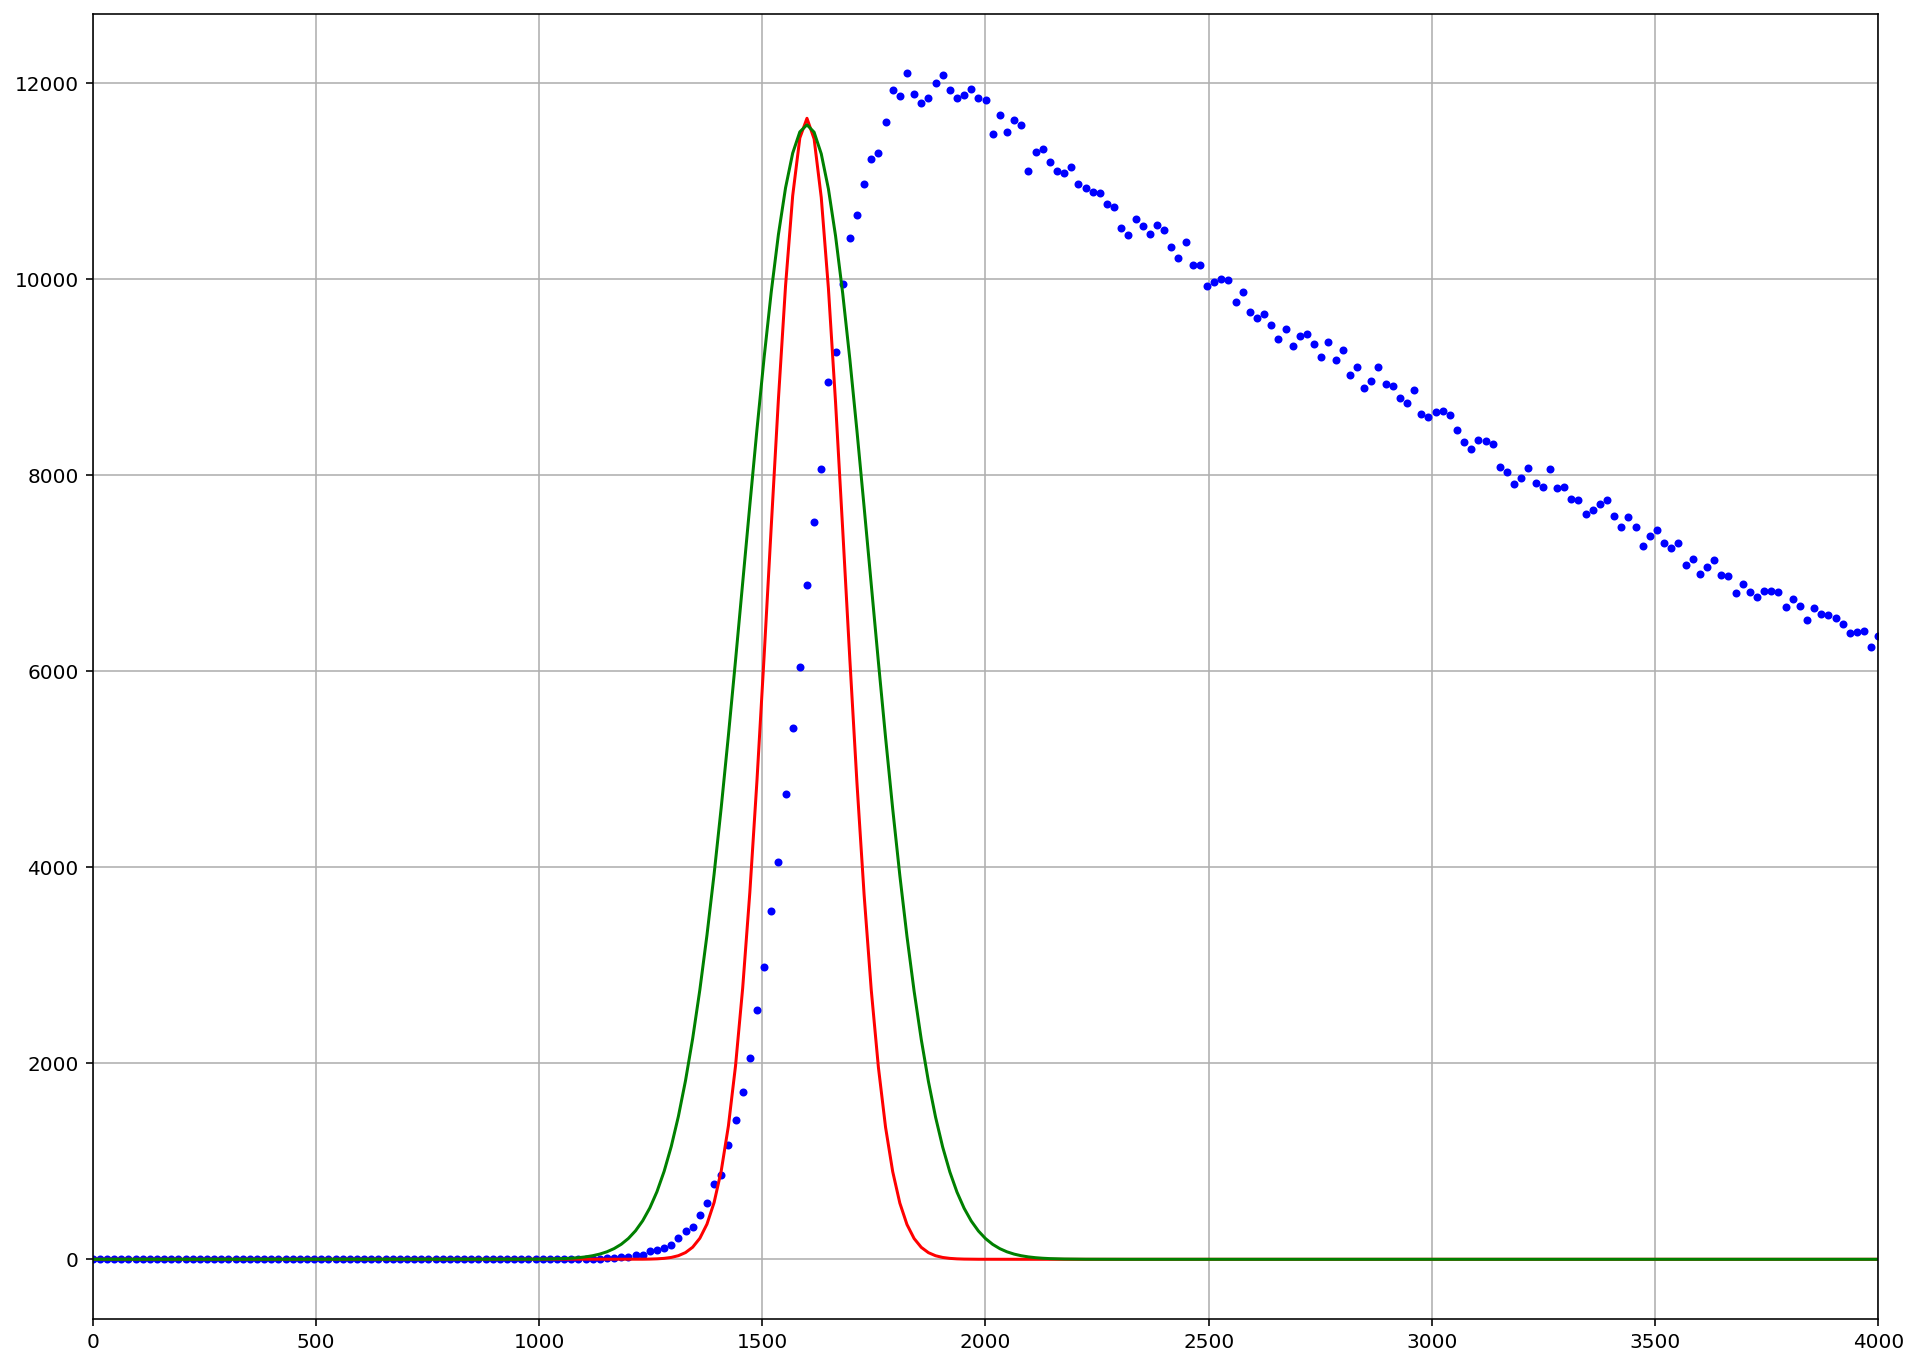

In [237]:
time_axis = pq.make_time_axis(
    global_resolution = 1/19450000,
    resolution = 1.6E-11,
)


def add_poisson_noise(data, offset):
    decay = np.random.poisson(data, len(data))
    decay += np.random.poisson(offset, len(decay))
    return(decay)

simulated = fit.convoluted_decay(
    t = time_axis,
    offset = 1,
    amp = 5000,
    tau = 3210,
    IRF_mu = 1600,
    IRF_sigma = 60
)

simulated += fit.convoluted_decay(
    t = time_axis,
    offset = 1,
    amp = 10000,
    tau = 3210,
    IRF_mu = 1600,
    IRF_sigma = 100
)

simulated = add_poisson_noise(simulated, offset = 1)

IRF_1 = fit.gauss_laser(time_axis, 1600, 60)
IRF_2 = fit.gauss_laser(time_axis, 1600, 100)

plt.plot(time_axis, simulated, 'b.')
plt.plot(time_axis, 1750000*IRF_1, 'r-')
plt.plot(time_axis, 2900000*IRF_2, 'g-')
plt.yscale('linear')
plt.xlim(0, 4000)
plt.grid()
#plt.savefig('../../../../../Desktop/SimDecay_IRF_mu_diff.png', dpi = 350)
plt.show()


Reduced Chi-Squared: 1.5541891935464989


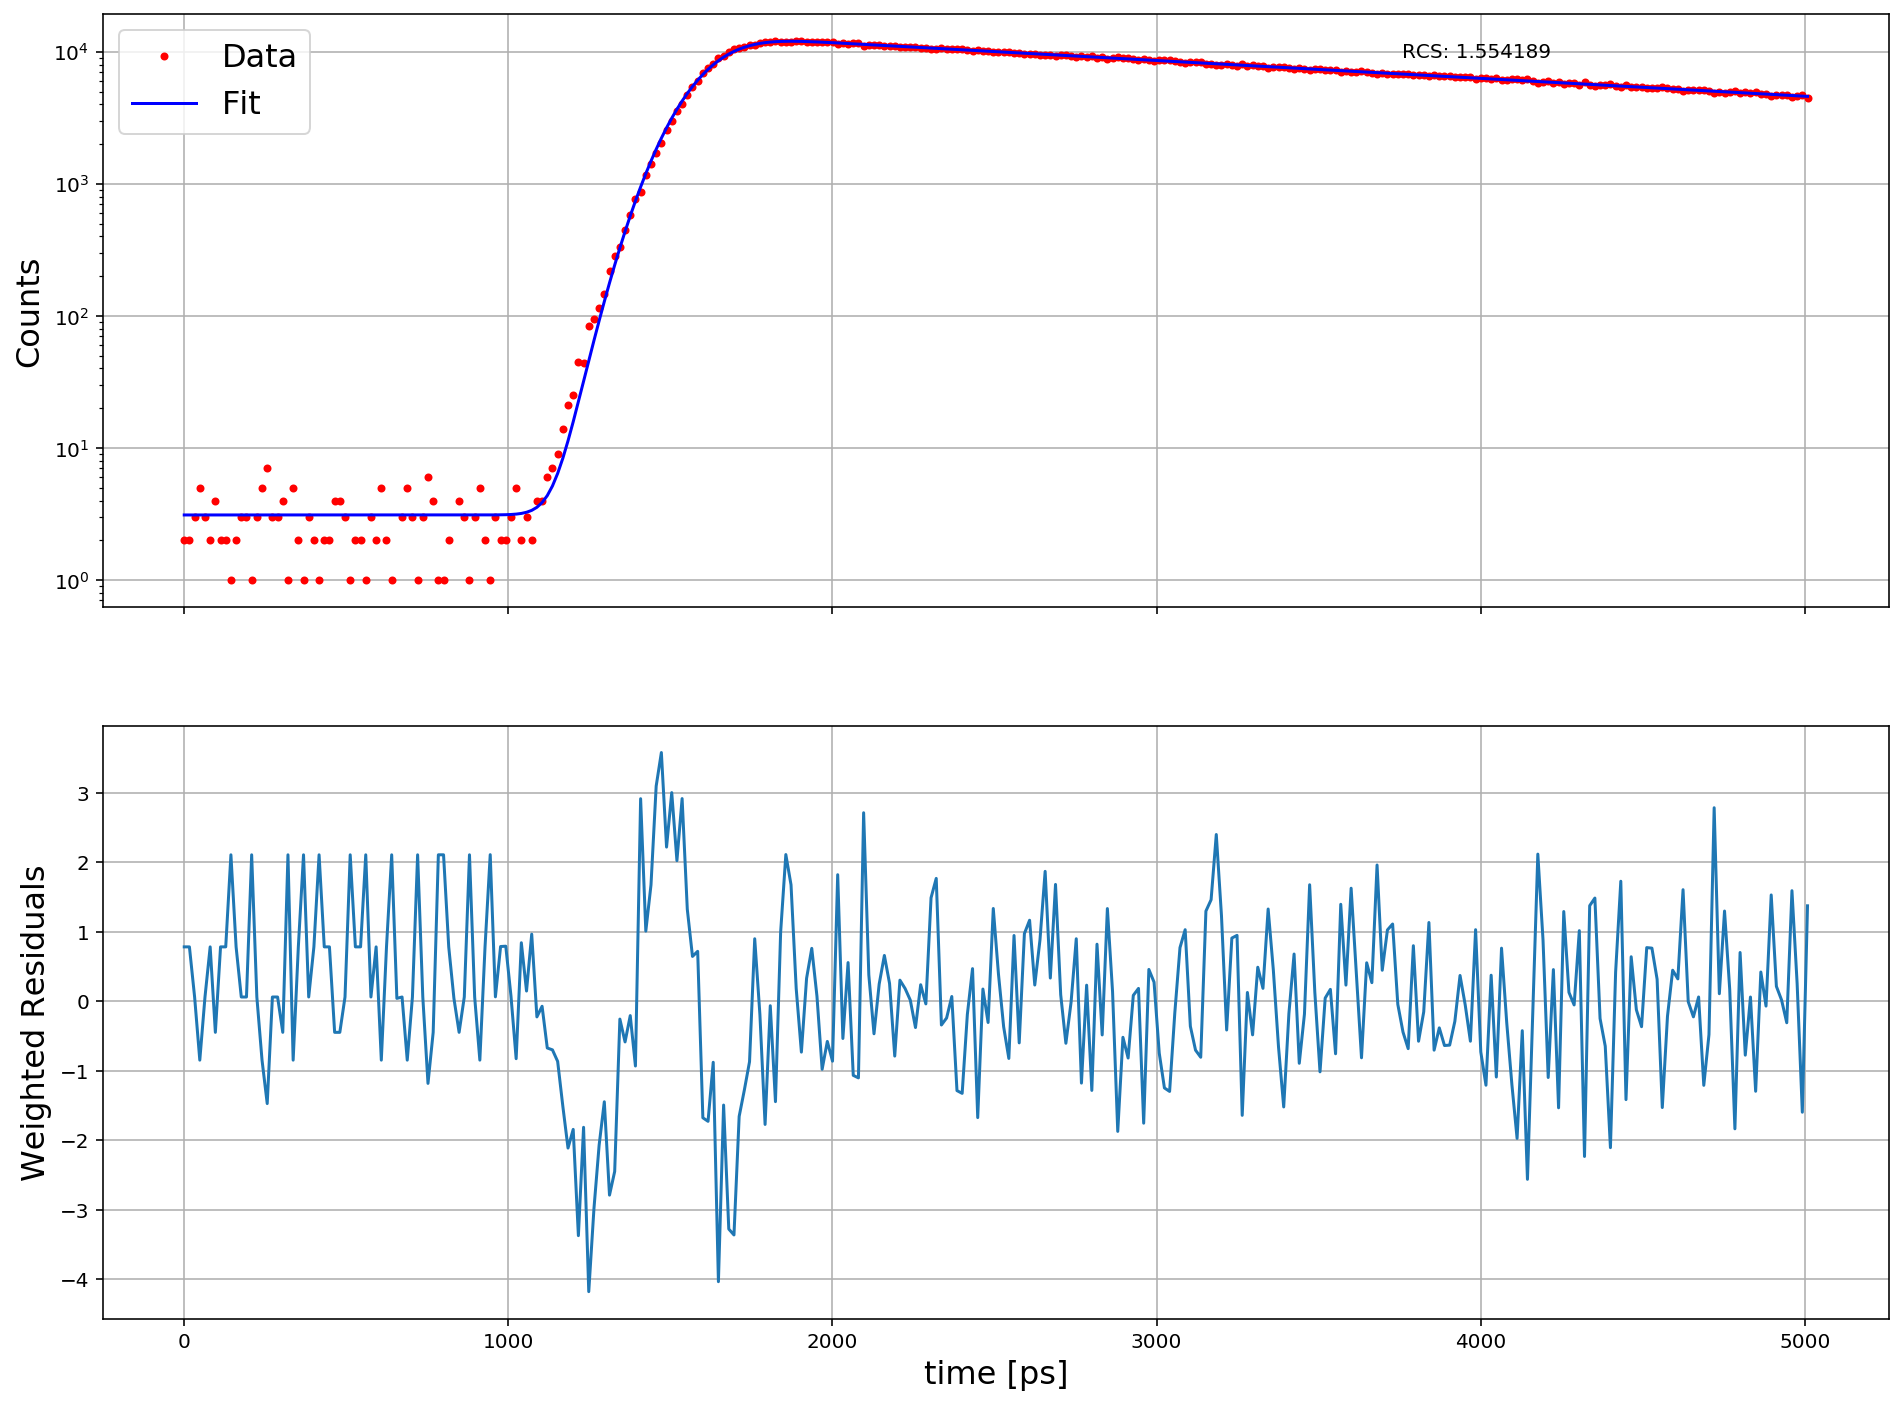

offset 		 3.1094563793833427
amplitude 		 15021.271921506797
tau 		 3209.52418017265
IRF_mu 		 1601.0667985560244
IRF_sigma 		 89.64907745586973


In [238]:
# Fitting simulated data
parameter_names, estimated_parameters, parameter_bounds = fit.make_start_parameters(
    offset = 2,
    amplitude = max(simulated),
   # Scatter_amplitude = 100,
    tau = 2000
)

simulated_fit = fit.fit_decay(
    simulated,
    time_axis,
    estimated_parameters,
    parameter_bounds,
    cutoff = 500,
    minimization_method = 'SLSQP'
)


fit.plot_fit(simulated, time_axis, simulated_fit, cutoff = 2900, scale = 'log')

for i in range(0, len(parameter_names)):
    print(parameter_names[i], '\t\t', simulated_fit['x'][i])


## Coumarin 6, 500 Integrations (45 min @ ~ 10 kCPS)
### Transient Expression

In [134]:
ptu_path = '../../../FLIM Data/20200318_Coumarin6_Long_Integration/200318_Coumarin_Long_Integration.sptw/200318_Coumarin6_LongIntegration_1/200318_Coumarin6_LongIntegration_1_1.ptu'
EGFP_cell_fa, EGFP_cell_ii, time_axis= pq.load_flim_data(
    path = ptu_path,
    channel = 0,
    spatialBinning = 3,
    temporalBinning = 1
)



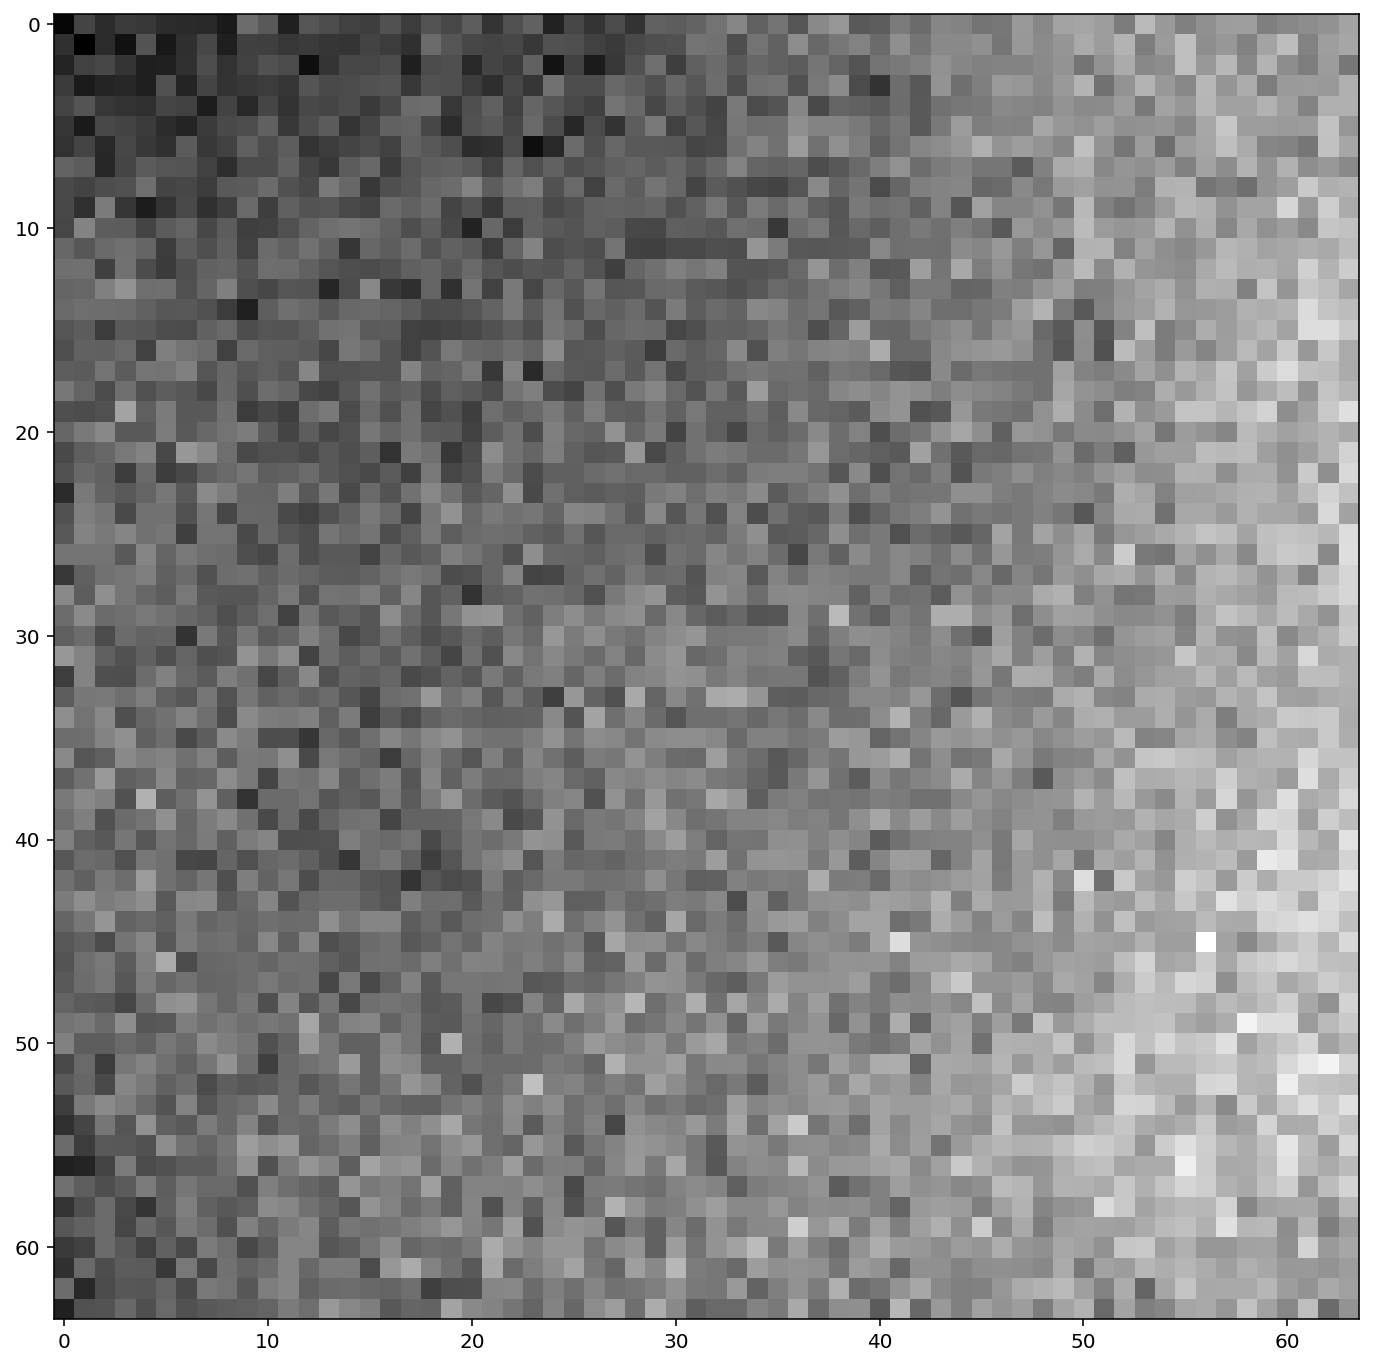

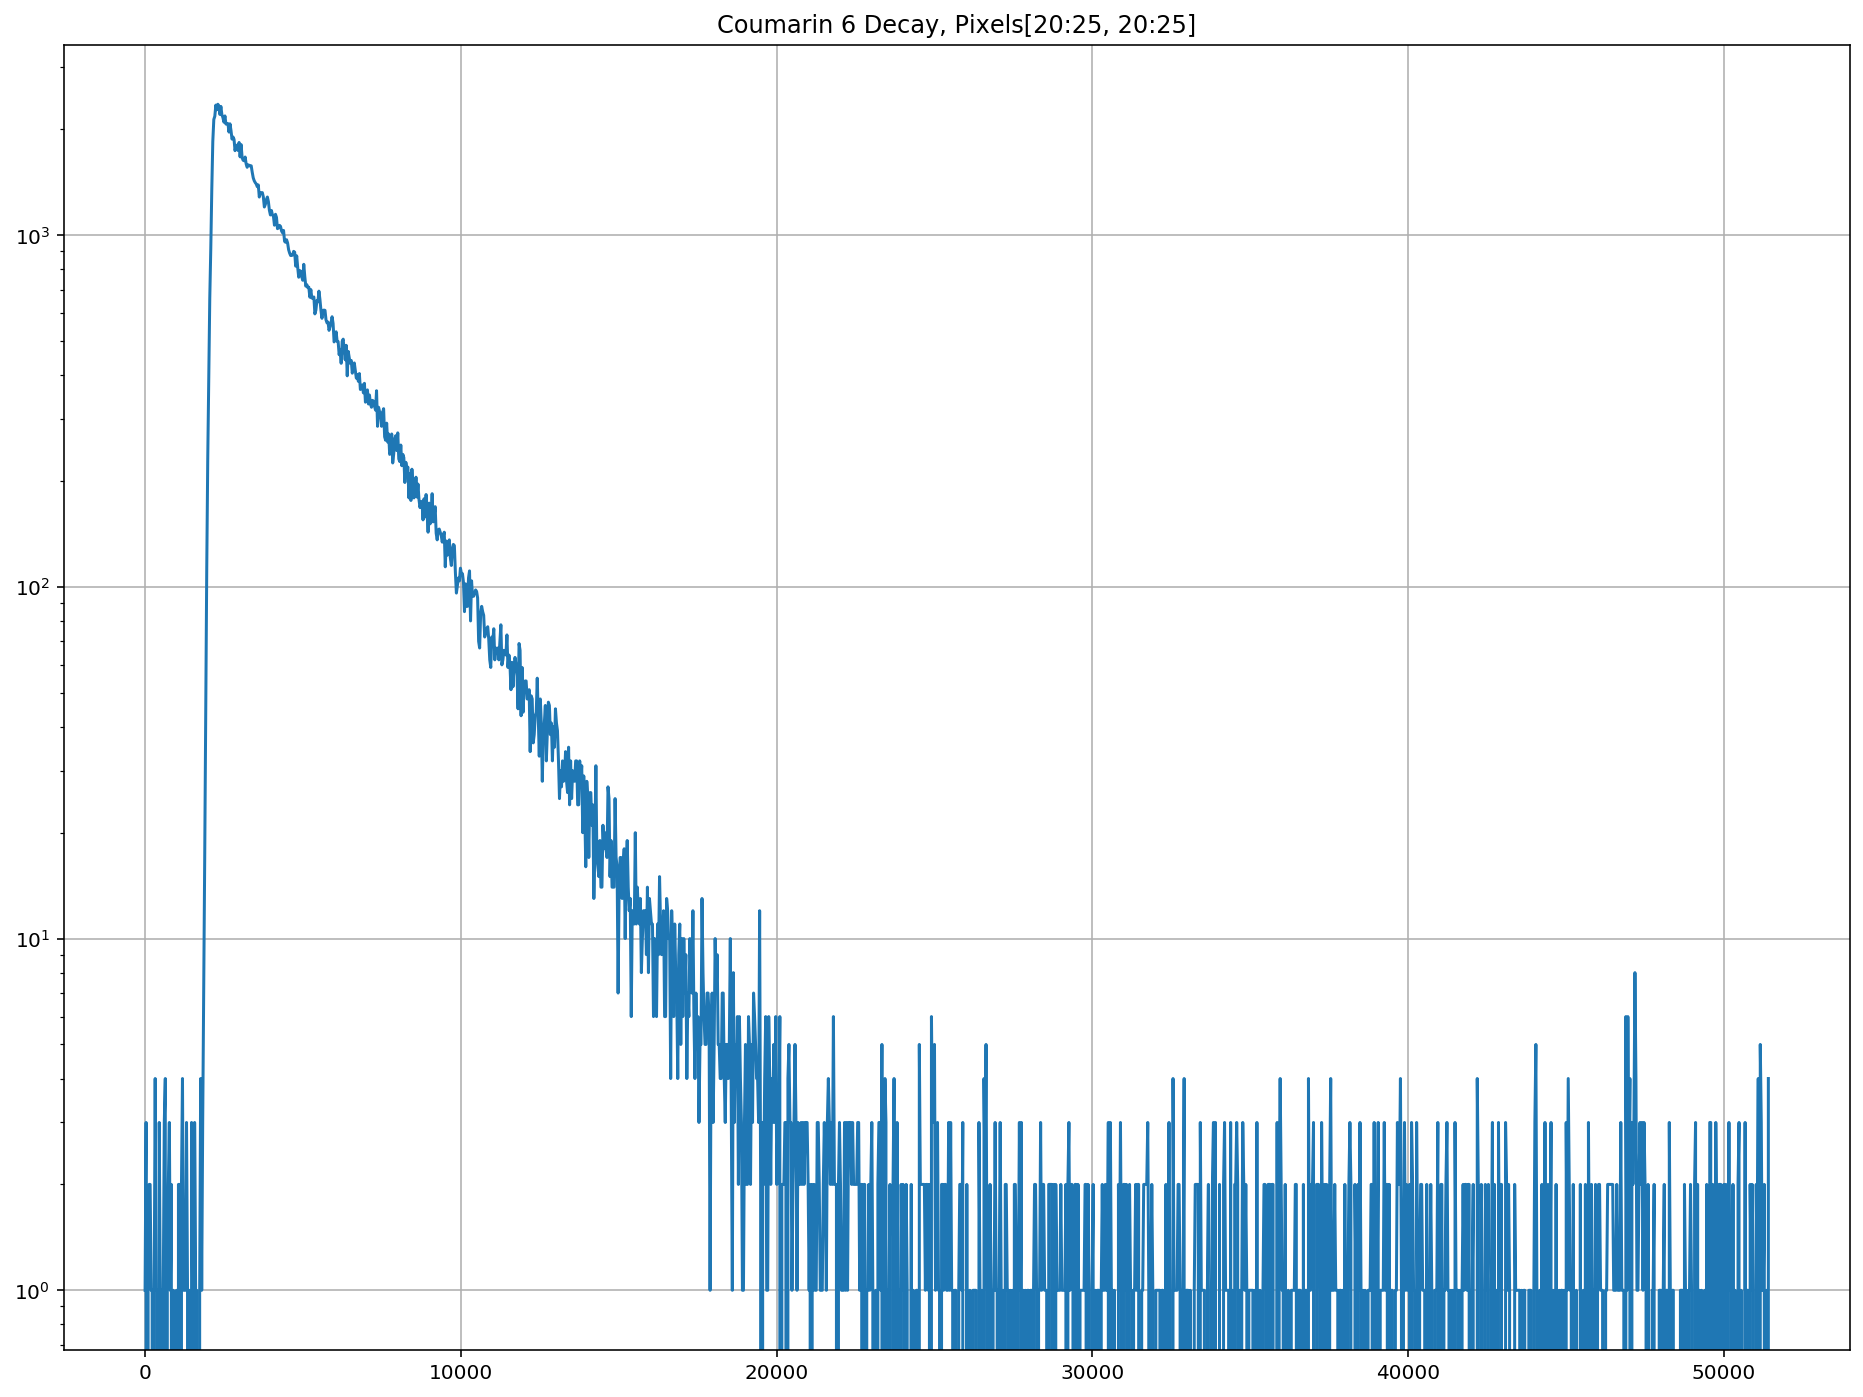

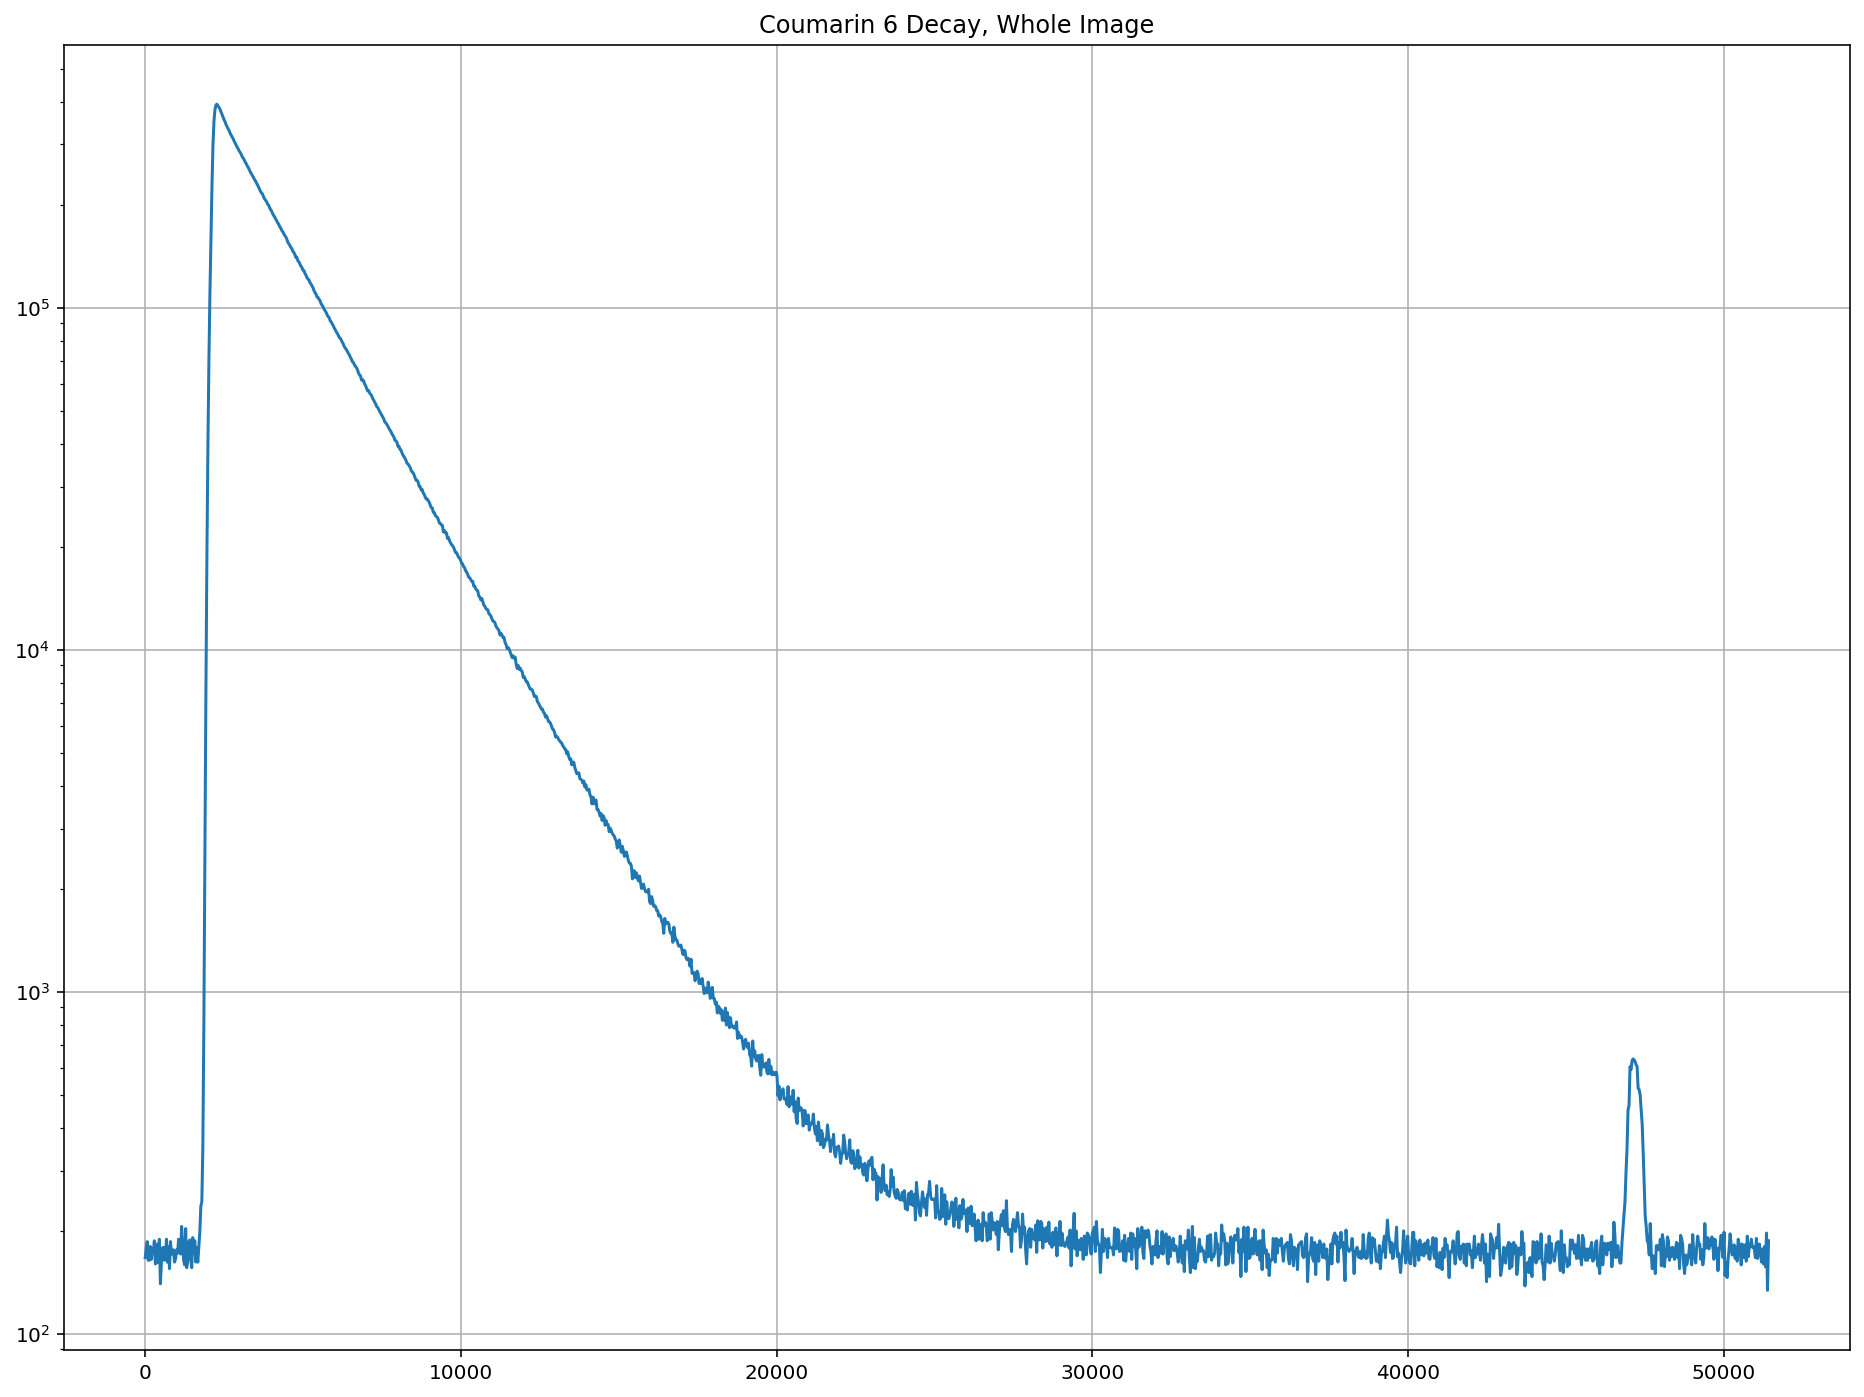

In [135]:
plt.imshow(EGFP_cell_ii, cmap = 'gray')
plt.show()

EGFP_decay_all = fit.sum_up_decay(EGFP_cell_fa)
EGFP_decay = fit.sum_up_decay(EGFP_cell_fa[20:25, 20:25, :])

plt.plot(time_axis, EGFP_decay)
plt.yscale('log')
plt.grid()
plt.title('Coumarin 6 Decay, Pixels[20:25, 20:25]')
plt.show()

plt.plot(time_axis, EGFP_decay_all)
plt.grid()
plt.yscale('log')
plt.title('Coumarin 6 Decay, Whole Image')
plt.show()

### Fitting Decay from Whole Image

Reduced Chi-Squared: 16.993744814937553


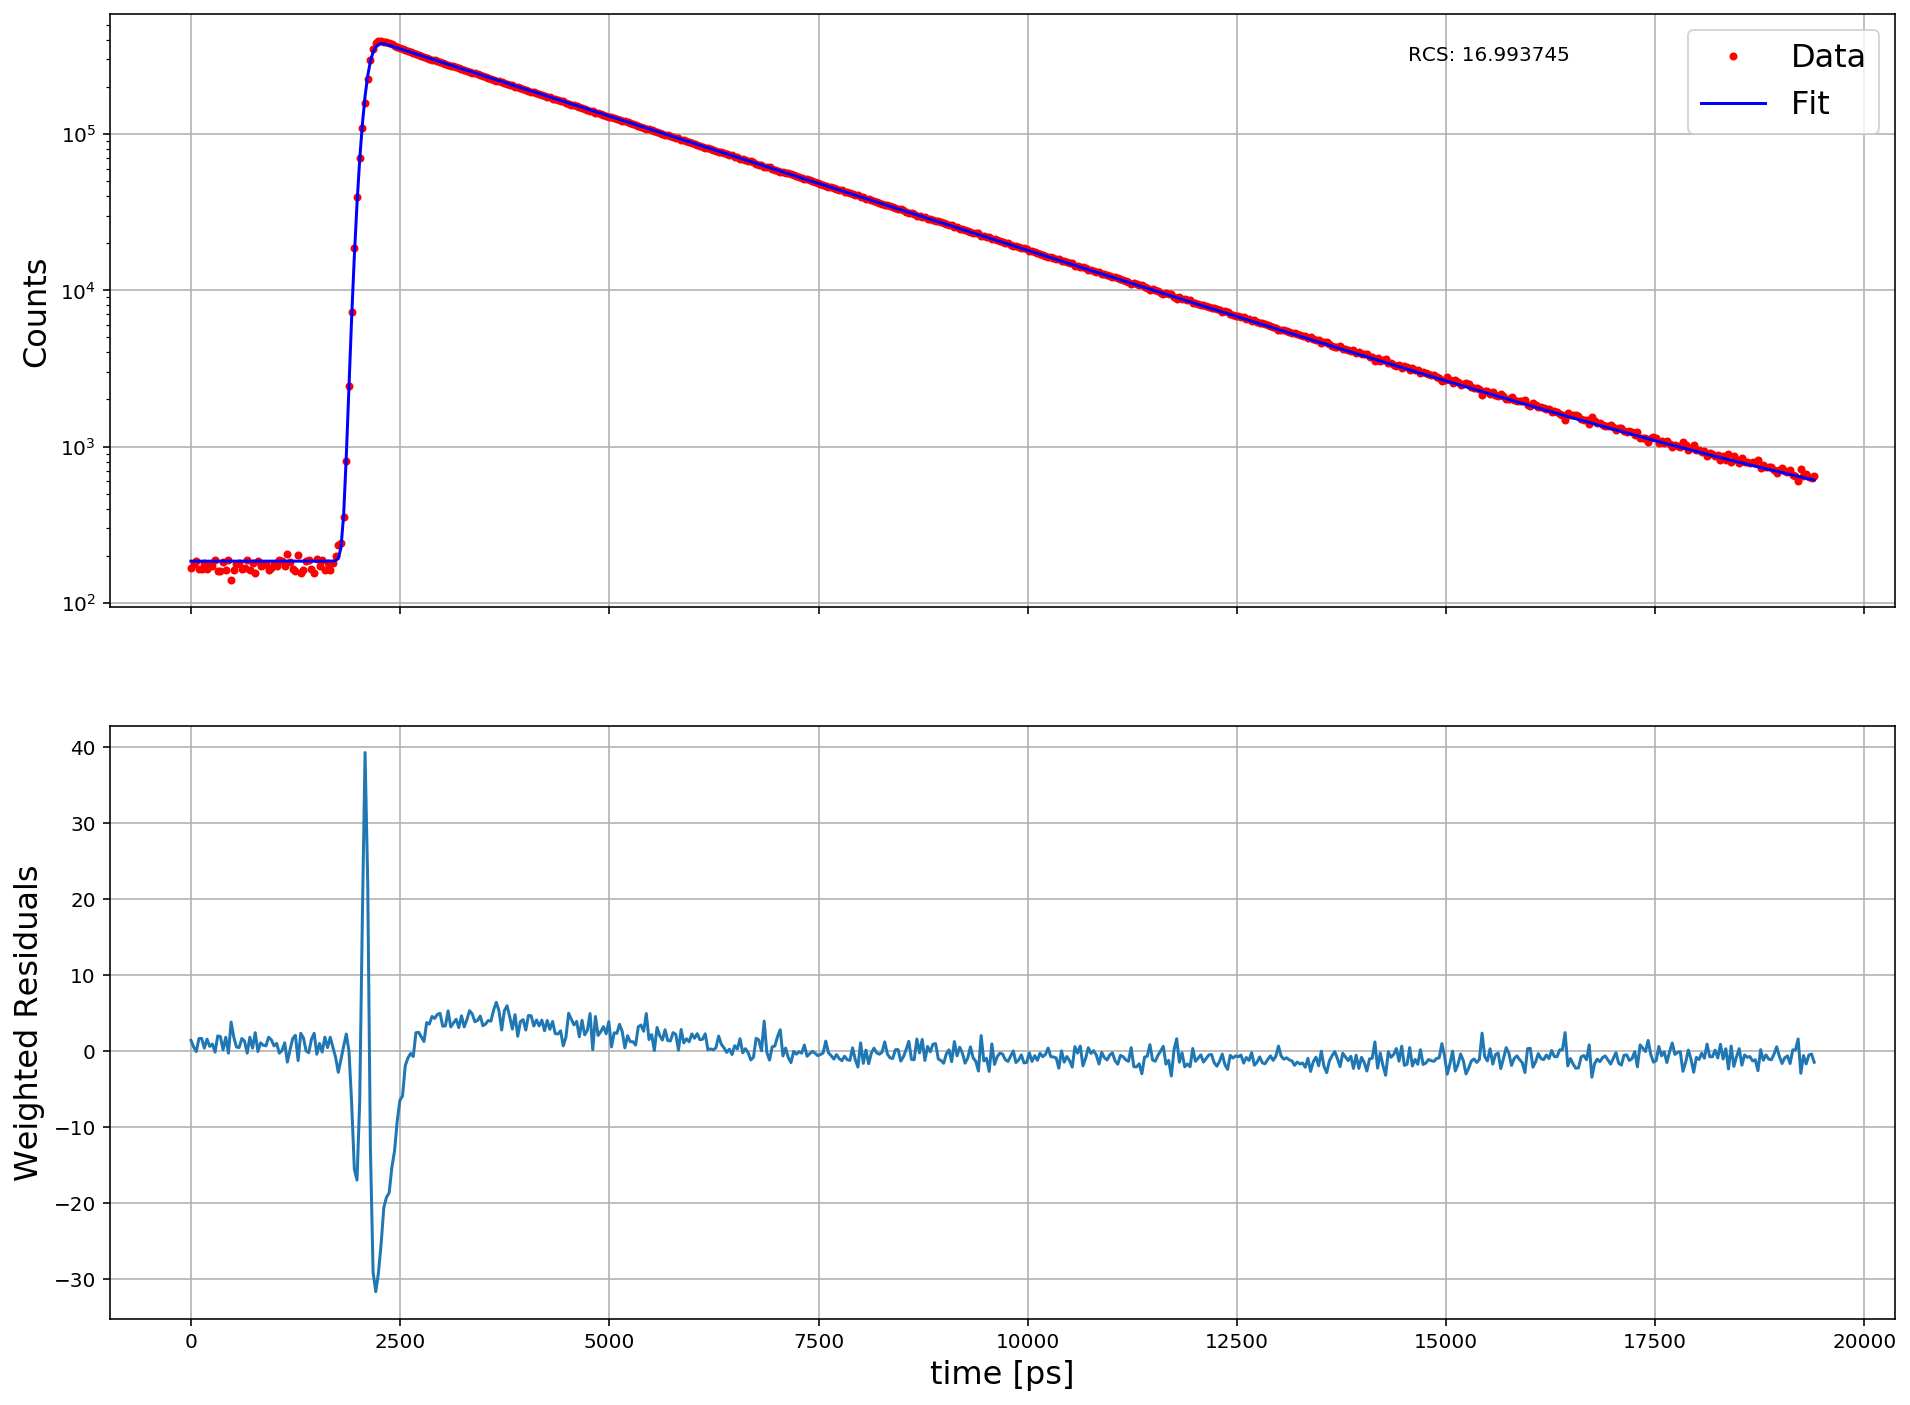

offset 		 184.77133317534137
amplitude 		 924161.0420926696
tau 		 2518.2472986918433
IRF_mu 		 2110.4195981873363
IRF_sigma 		 57.68468554461272


In [136]:
# Fitting Decay of Whole Image

parameter_names, estimated_parameters, parameter_bounds = fit.make_start_parameters(
    offset = 2,
    amplitude = max(EGFP_decay_all),
    #Scatter_amplitude = 0,
    tau = 2000
    #IRF_sigma = 25
)

EGFP_fit = fit.fit_decay(
    EGFP_decay_all,
    time_axis,
    estimated_parameters,
    parameter_bounds,
    cutoff = 500,
    minimization_method = 'SLSQP'
)

fit.plot_fit(EGFP_decay_all, time_axis, EGFP_fit, cutoff = 1000, scale = 'log')

for i in range(0, len(parameter_names)):
    print(parameter_names[i], '\t\t', EGFP_fit['x'][i])

### Fitting Selected Pixels[20:25, 20:25]

In [139]:
parameter_names, estimated_parameters, parameter_bounds = fit.make_start_parameters(
    offset = 2,
    amplitude = max(EGFP_decay),
    #Scatter_amplitude = 0,
    tau = 2500
    #IRF_sigma = 25
)

EGFP_fit = fit.fit_decay(
    EGFP_decay,
    time_axis,
    estimated_parameters,
    parameter_bounds,
    cutoff = 500,
    minimization_method = 'SLSQP'
)


Reduced Chi-Squared: 0.9155541426067868


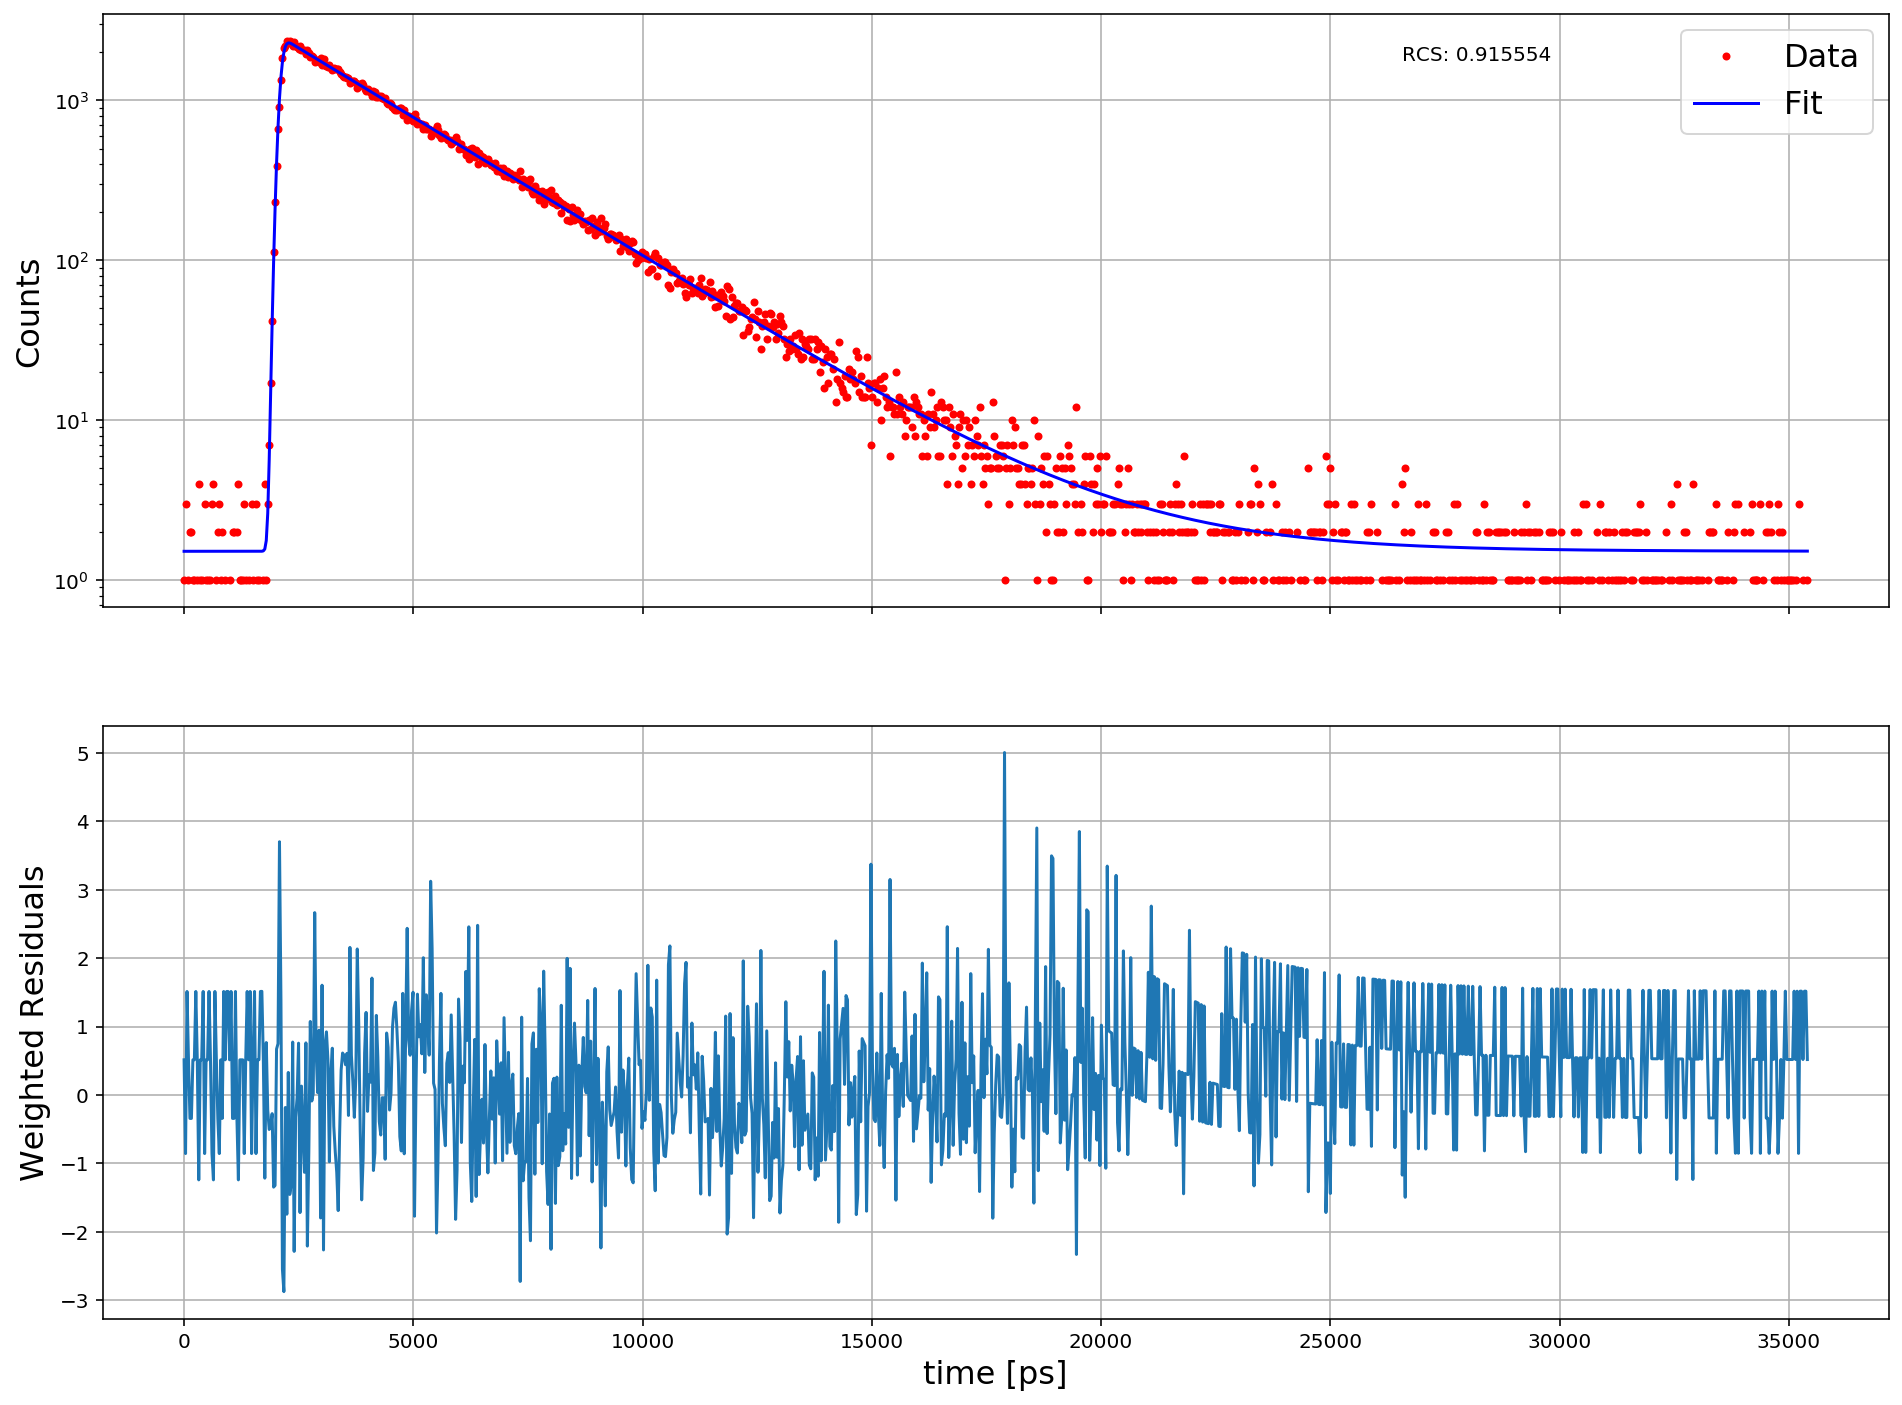

offset 		 1.512479095401751
amplitude 		 5611.005045944019
tau 		 2499.9032971963875
IRF_mu 		 2113.1384352385035
IRF_sigma 		 58.331196443273555


In [140]:
fit.plot_fit(EGFP_decay, time_axis, EGFP_fit, cutoff = 500, scale = 'log')

for i in range(0, len(parameter_names)):
    print(parameter_names[i], '\t\t', EGFP_fit['x'][i])

In [111]:
# Pixel-wise fitting

flim_image = np.zeros((EGFP_cell_fa.shape[0], EGFP_cell_fa.shape[1], EGFP_fit['x'].shape[0]))

for x in range(EGFP_cell_fa.shape[0]):
    for y in range(EGFP_cell_fa.shape[1]):
        estimated_parameters = EGFP_fit['x']
        if(np.sum(EGFP_cell_fa[x, y, :]) > 300):
            EGFP_fit = fit.fit_decay(
                EGFP_cell_fa[x, y, :],
                time_axis,
                estimated_parameters,
                parameter_bounds,
                cutoff = 750,
                minimization_method = 'SLSQP'
            )
            flim_image[x, y, :] = EGFP_fit['x']
    print('Proceeding to line', x)

Proceeding to line 0
Proceeding to line 1
Proceeding to line 2
Proceeding to line 3
Proceeding to line 4
Proceeding to line 5
Proceeding to line 6
Proceeding to line 7
Proceeding to line 8
Proceeding to line 9
Proceeding to line 10
Proceeding to line 11
Proceeding to line 12
Proceeding to line 13
Proceeding to line 14
Proceeding to line 15
Proceeding to line 16
Proceeding to line 17
Proceeding to line 18
Proceeding to line 19
Proceeding to line 20
Proceeding to line 21
Proceeding to line 22
Proceeding to line 23
Proceeding to line 24
Proceeding to line 25
Proceeding to line 26
Proceeding to line 27
Proceeding to line 28
Proceeding to line 29
Proceeding to line 30
Proceeding to line 31
Proceeding to line 32
Proceeding to line 33
Proceeding to line 34
Proceeding to line 35
Proceeding to line 36
Proceeding to line 37
Proceeding to line 38
Proceeding to line 39
Proceeding to line 40
Proceeding to line 41
Proceeding to line 42
Proceeding to line 43
Proceeding to line 44
Proceeding to line 4

/home/tom/Documents/PhD/Repositories/PhasorFLIM/notebooks/flim_fitting_functions.py:143: RuntimeWarning: divide by zero encountered in true_divide
  data * np.log(data / fitted) - (data - fitted)
/home/tom/Documents/PhD/Repositories/PhasorFLIM/notebooks/flim_fitting_functions.py:143: RuntimeWarning: invalid value encountered in true_divide
  data * np.log(data / fitted) - (data - fitted)


Proceeding to line 57
Proceeding to line 58
Proceeding to line 59
Proceeding to line 60
Proceeding to line 61
Proceeding to line 62
Proceeding to line 63


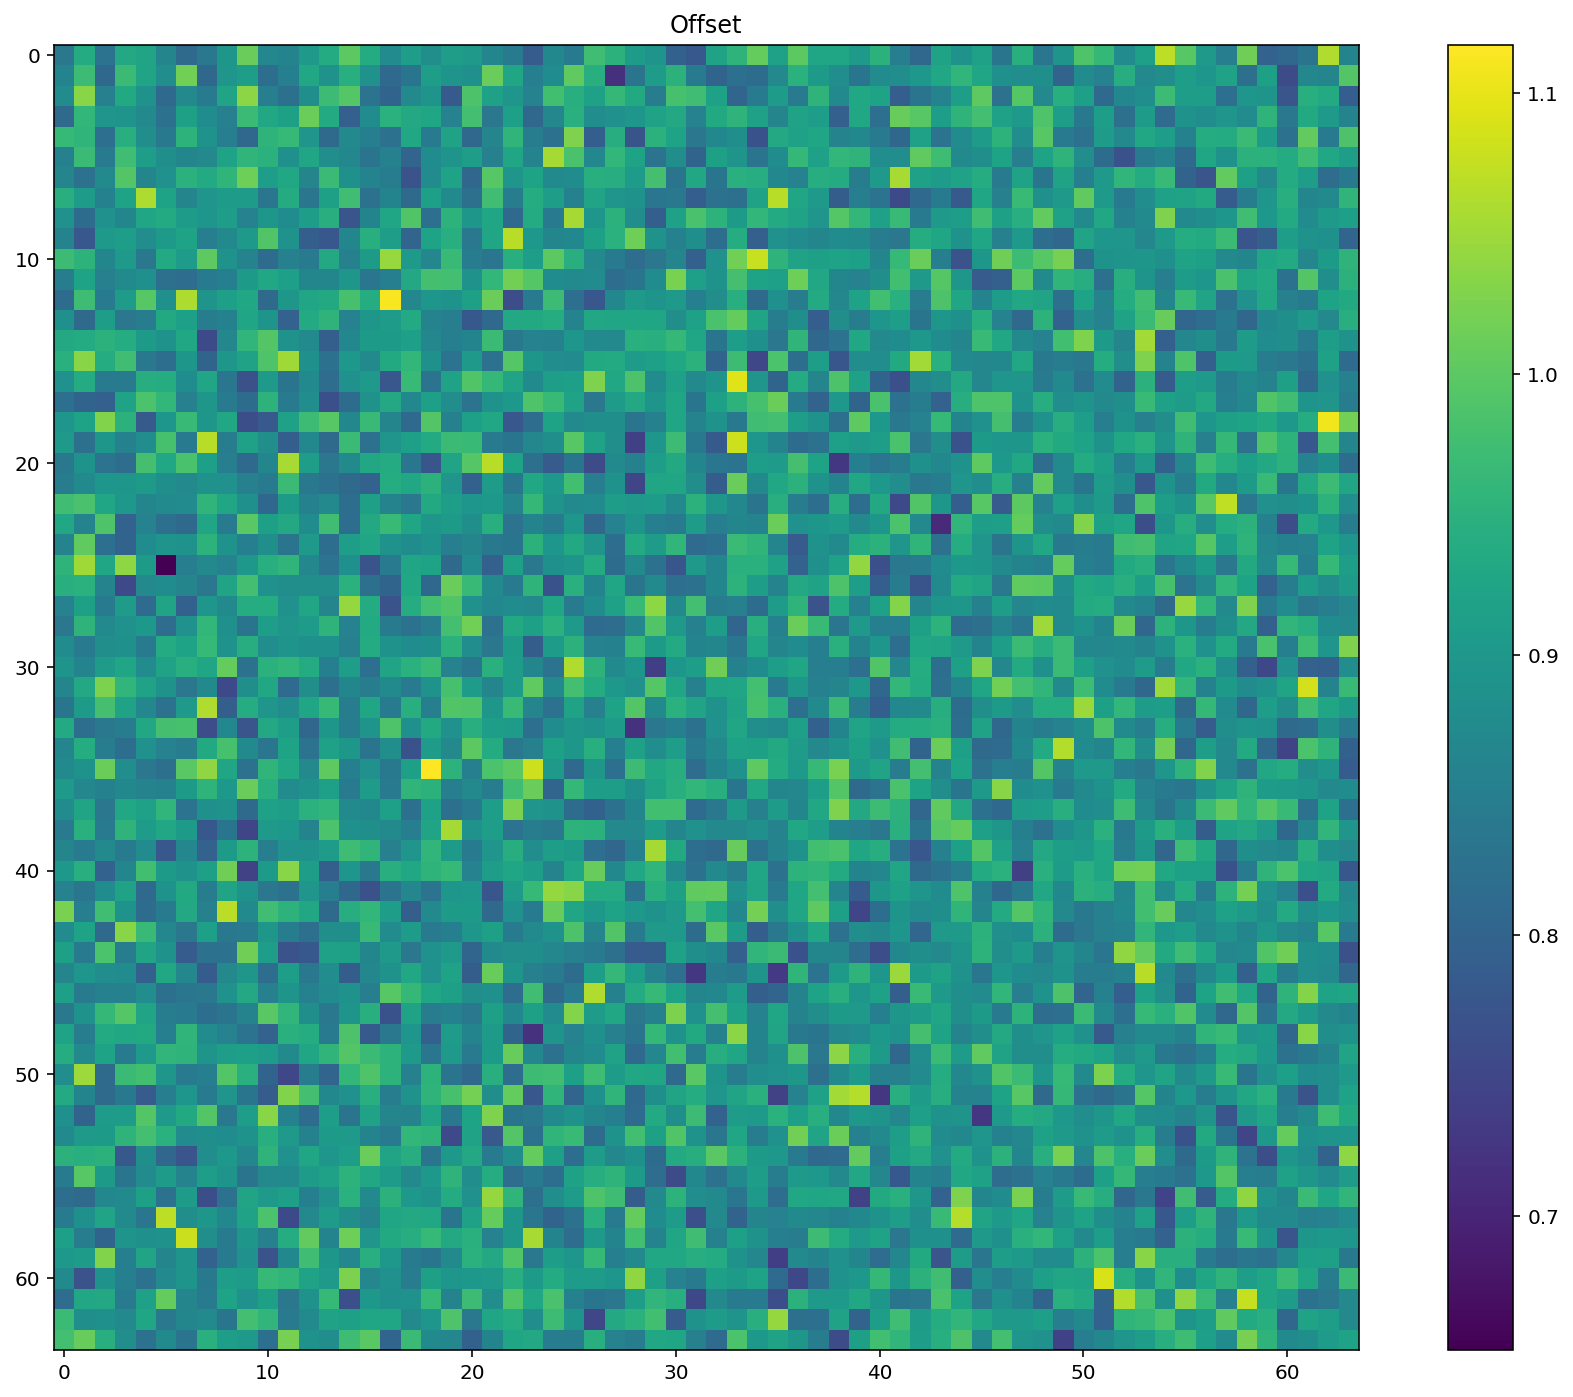

In [112]:
plt.imshow(flim_image[:, :, 0])
plt.title('Offset')
plt.colorbar()
plt.show()

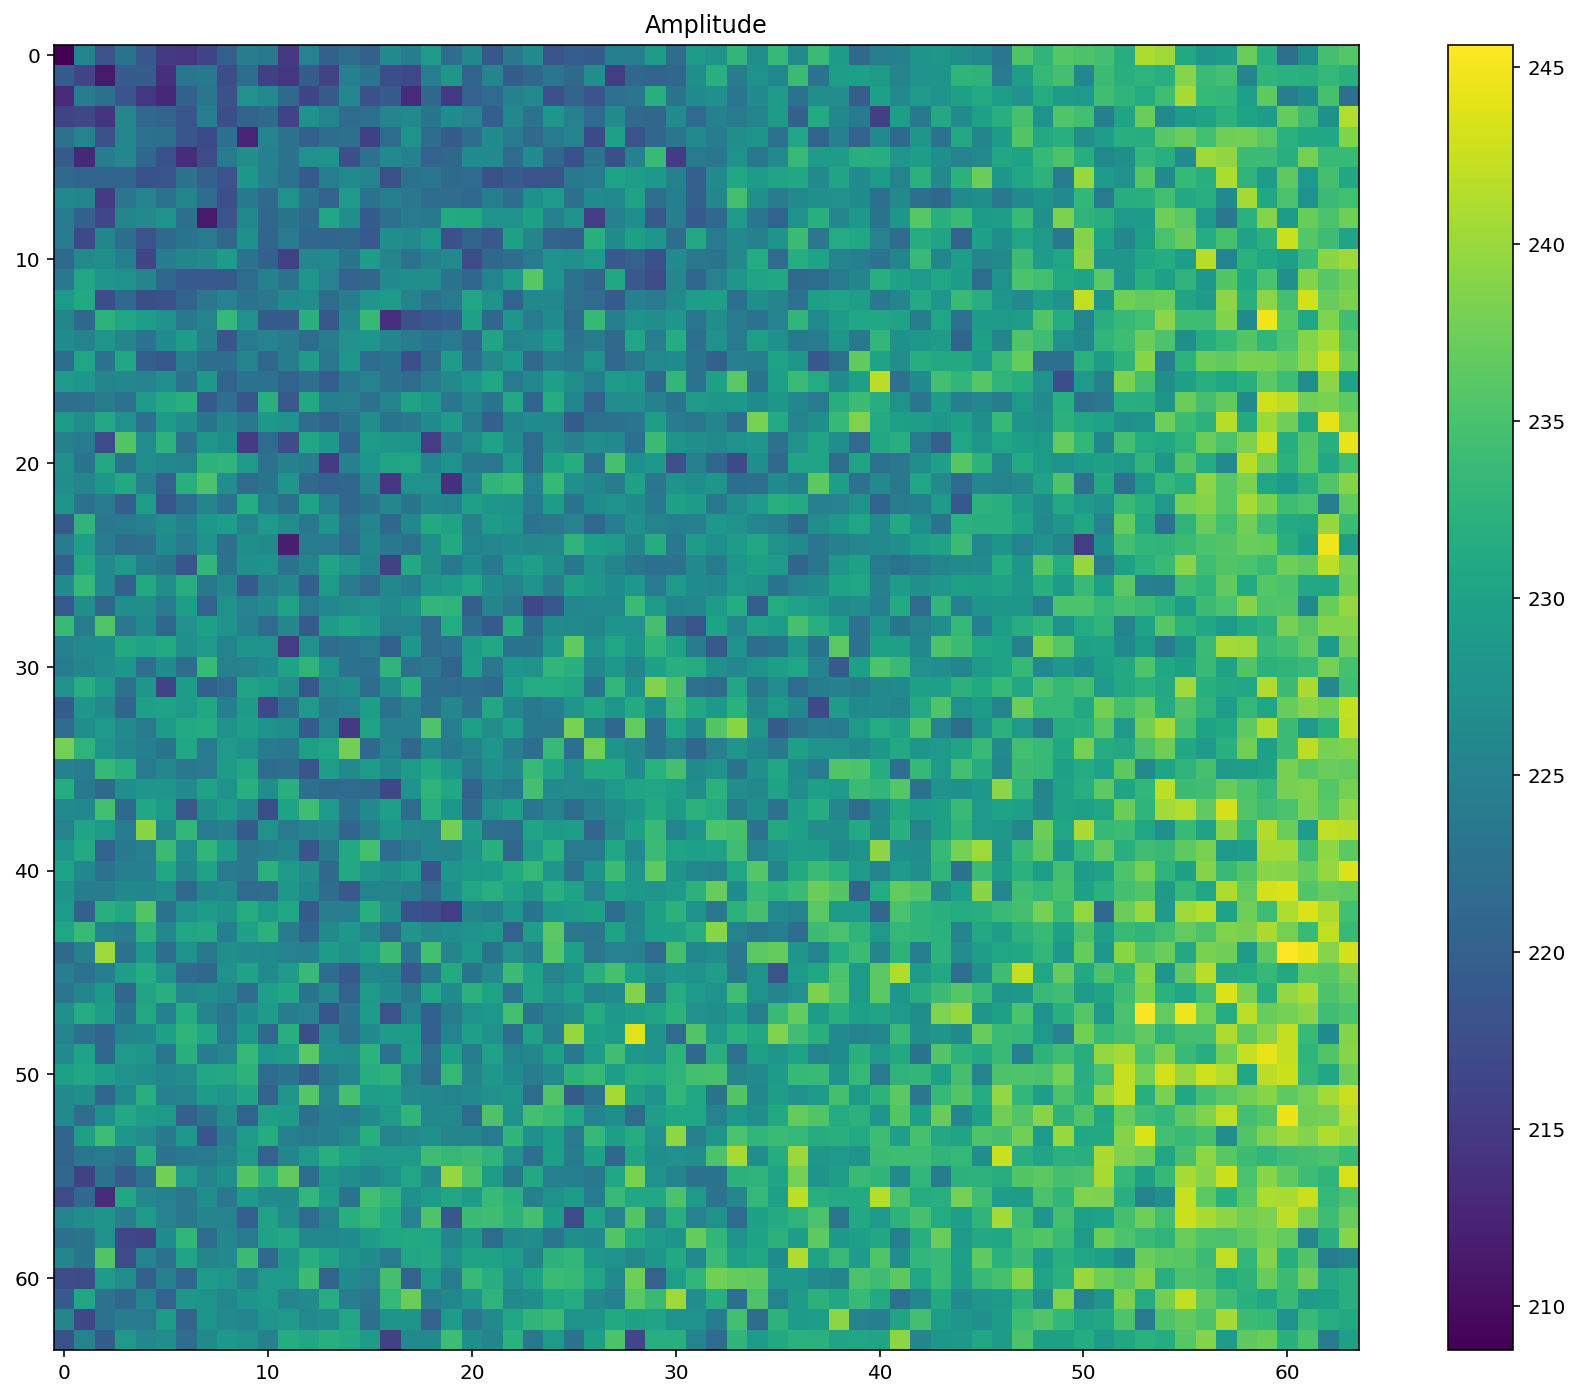

In [113]:
plt.imshow(flim_image[:, :, 1])
plt.title('Amplitude')
plt.colorbar()
plt.show()

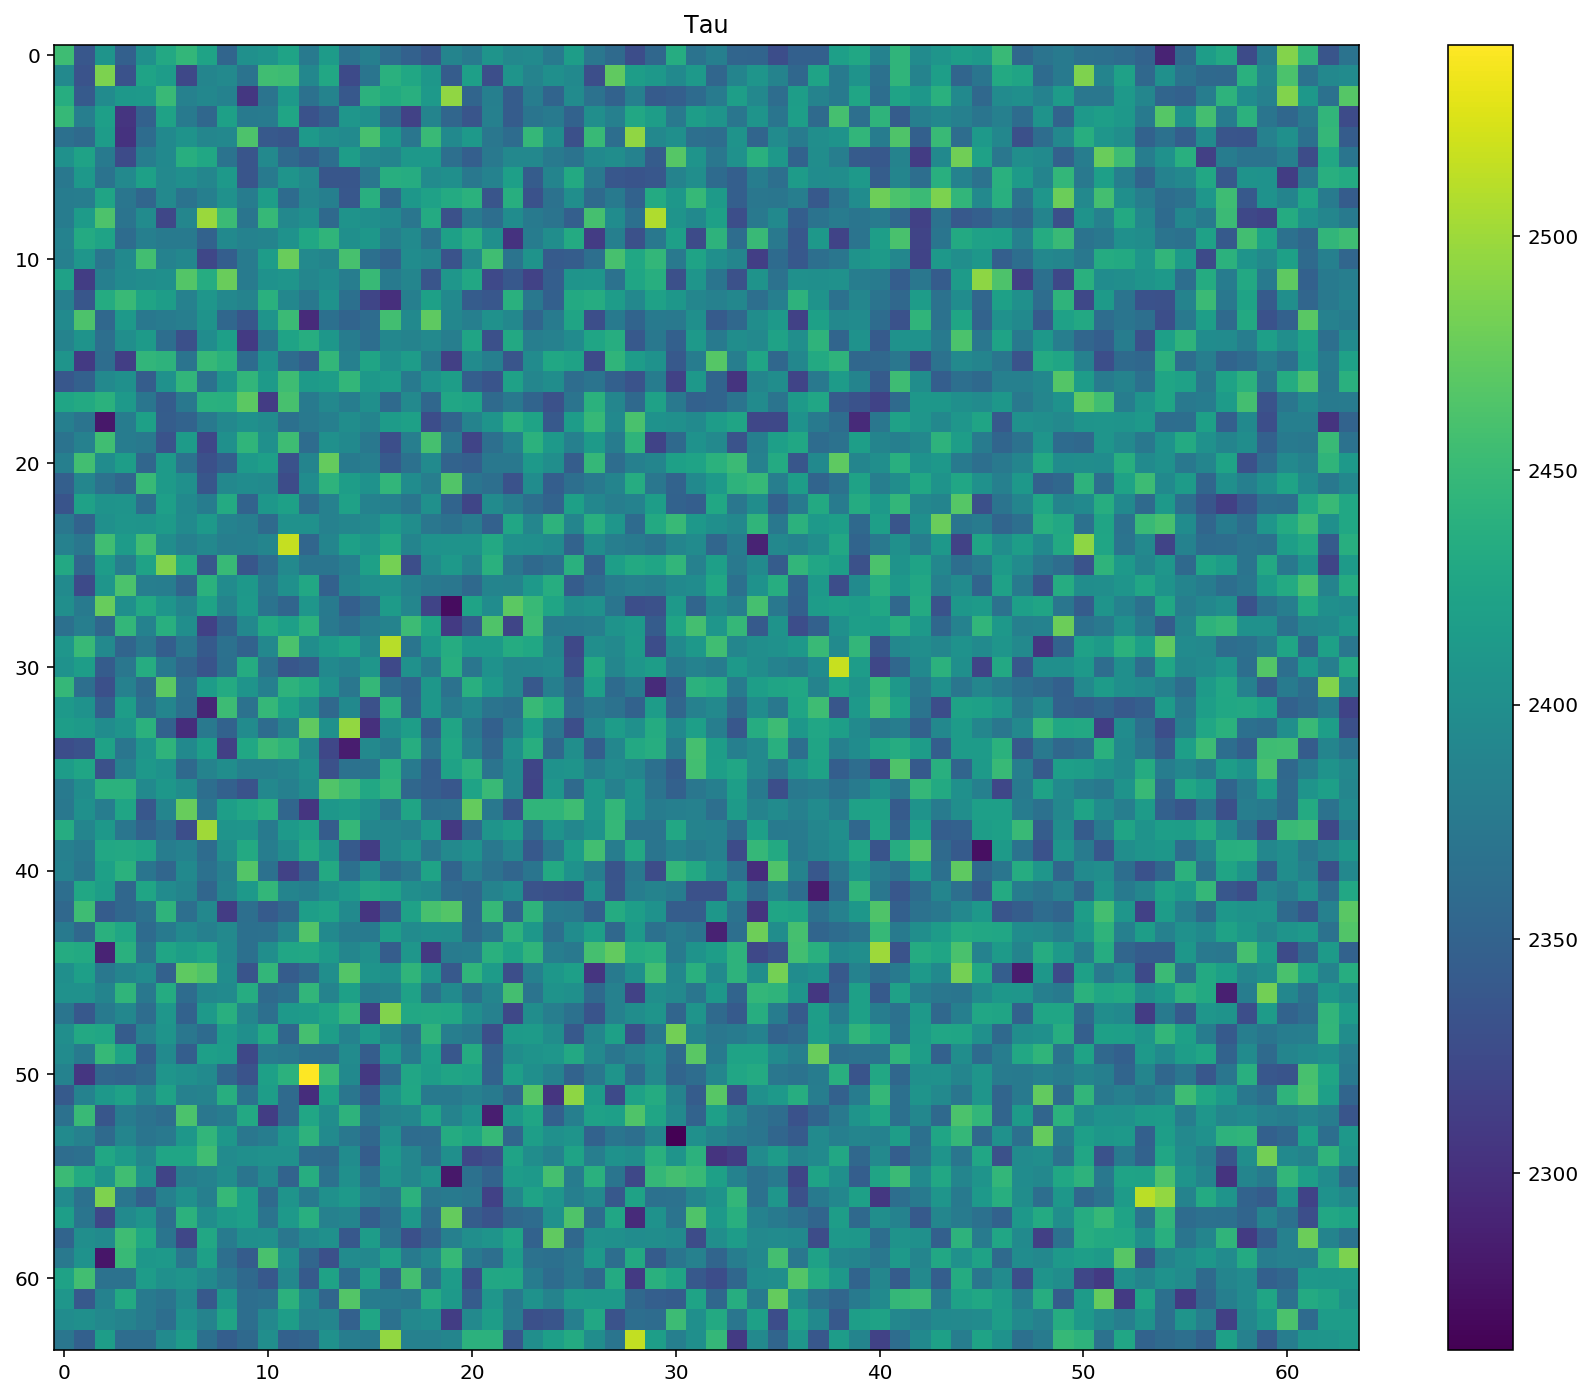

In [114]:
plt.imshow(flim_image[:, :, 2])
plt.title('Tau')
plt.colorbar()
plt.show()

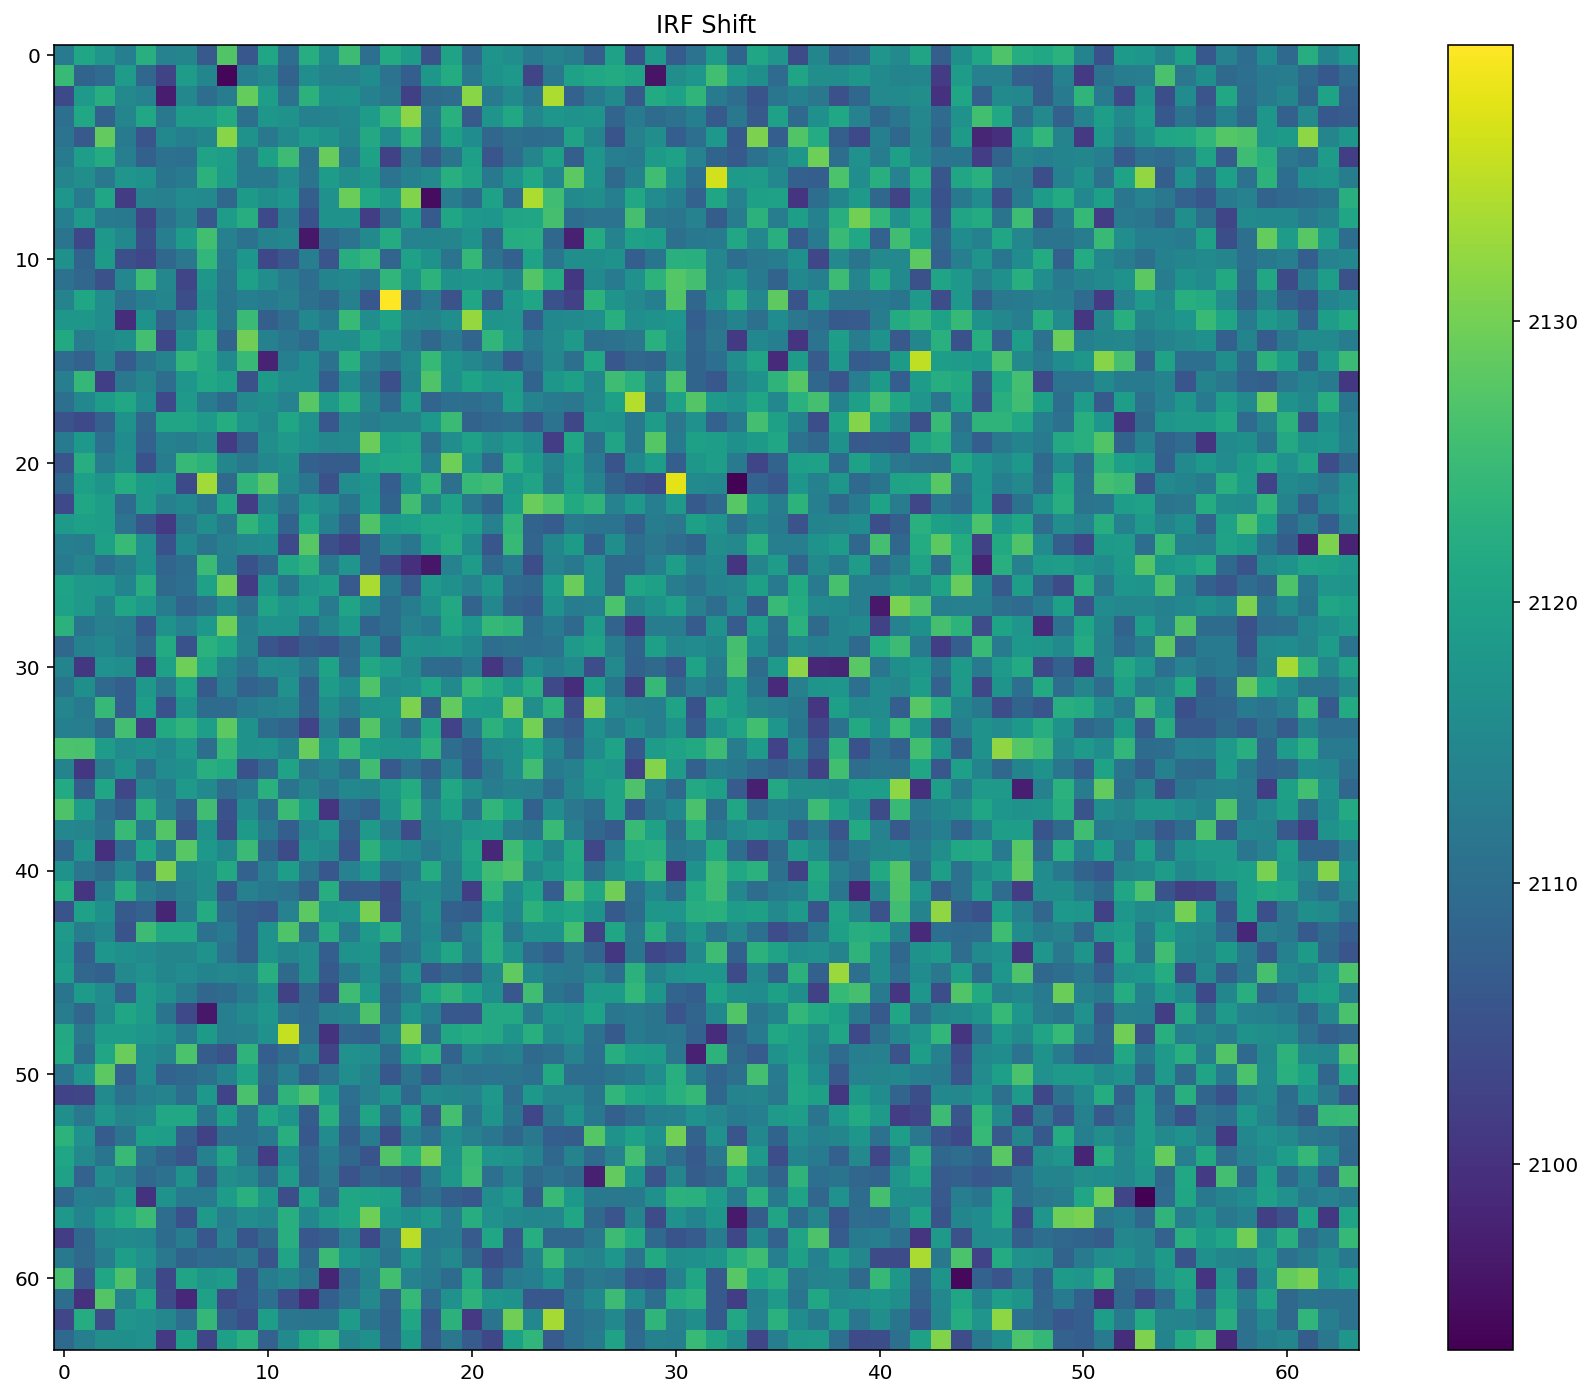

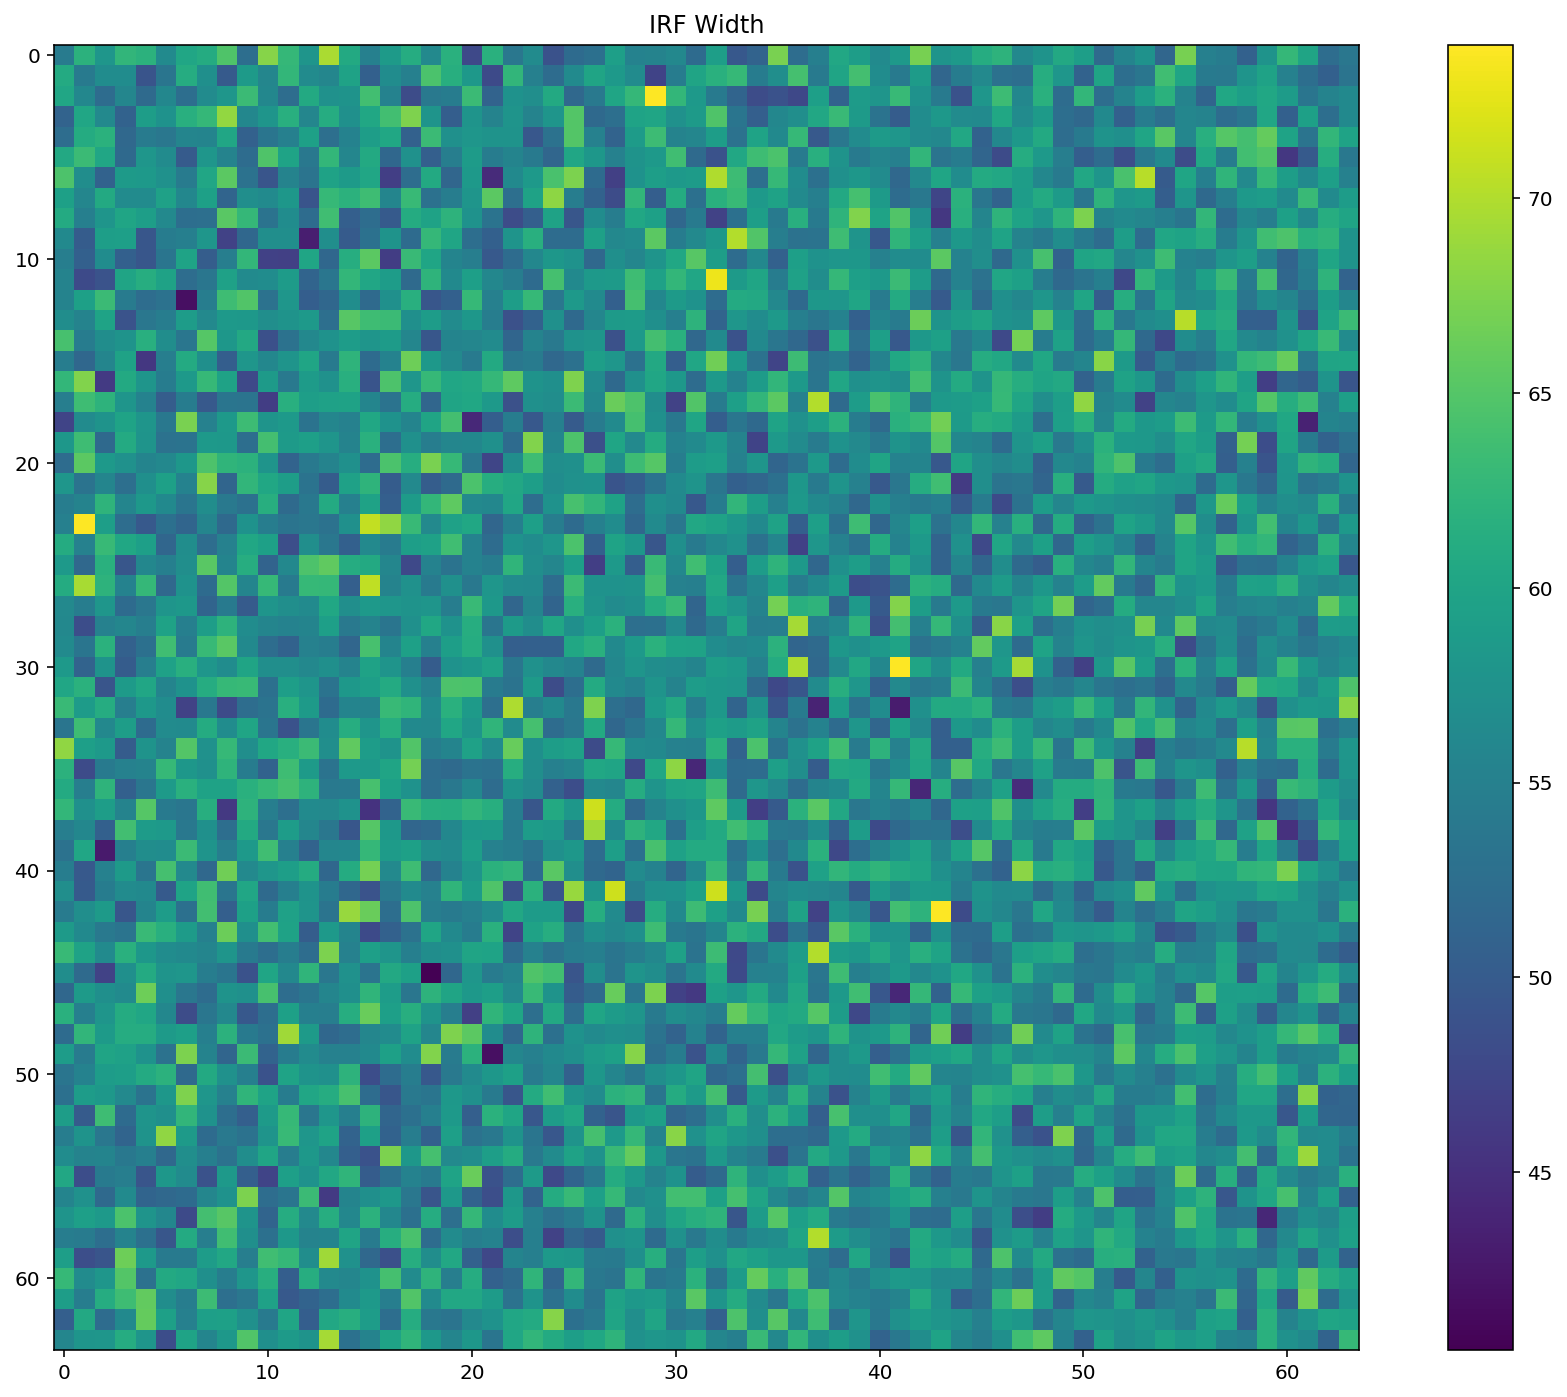

In [115]:
plt.imshow(flim_image[:, :, 3])
plt.title('IRF Shift')
plt.colorbar()
plt.show()

plt.imshow(flim_image[:, :, 4])
plt.title('IRF Width')
plt.colorbar()
plt.show()

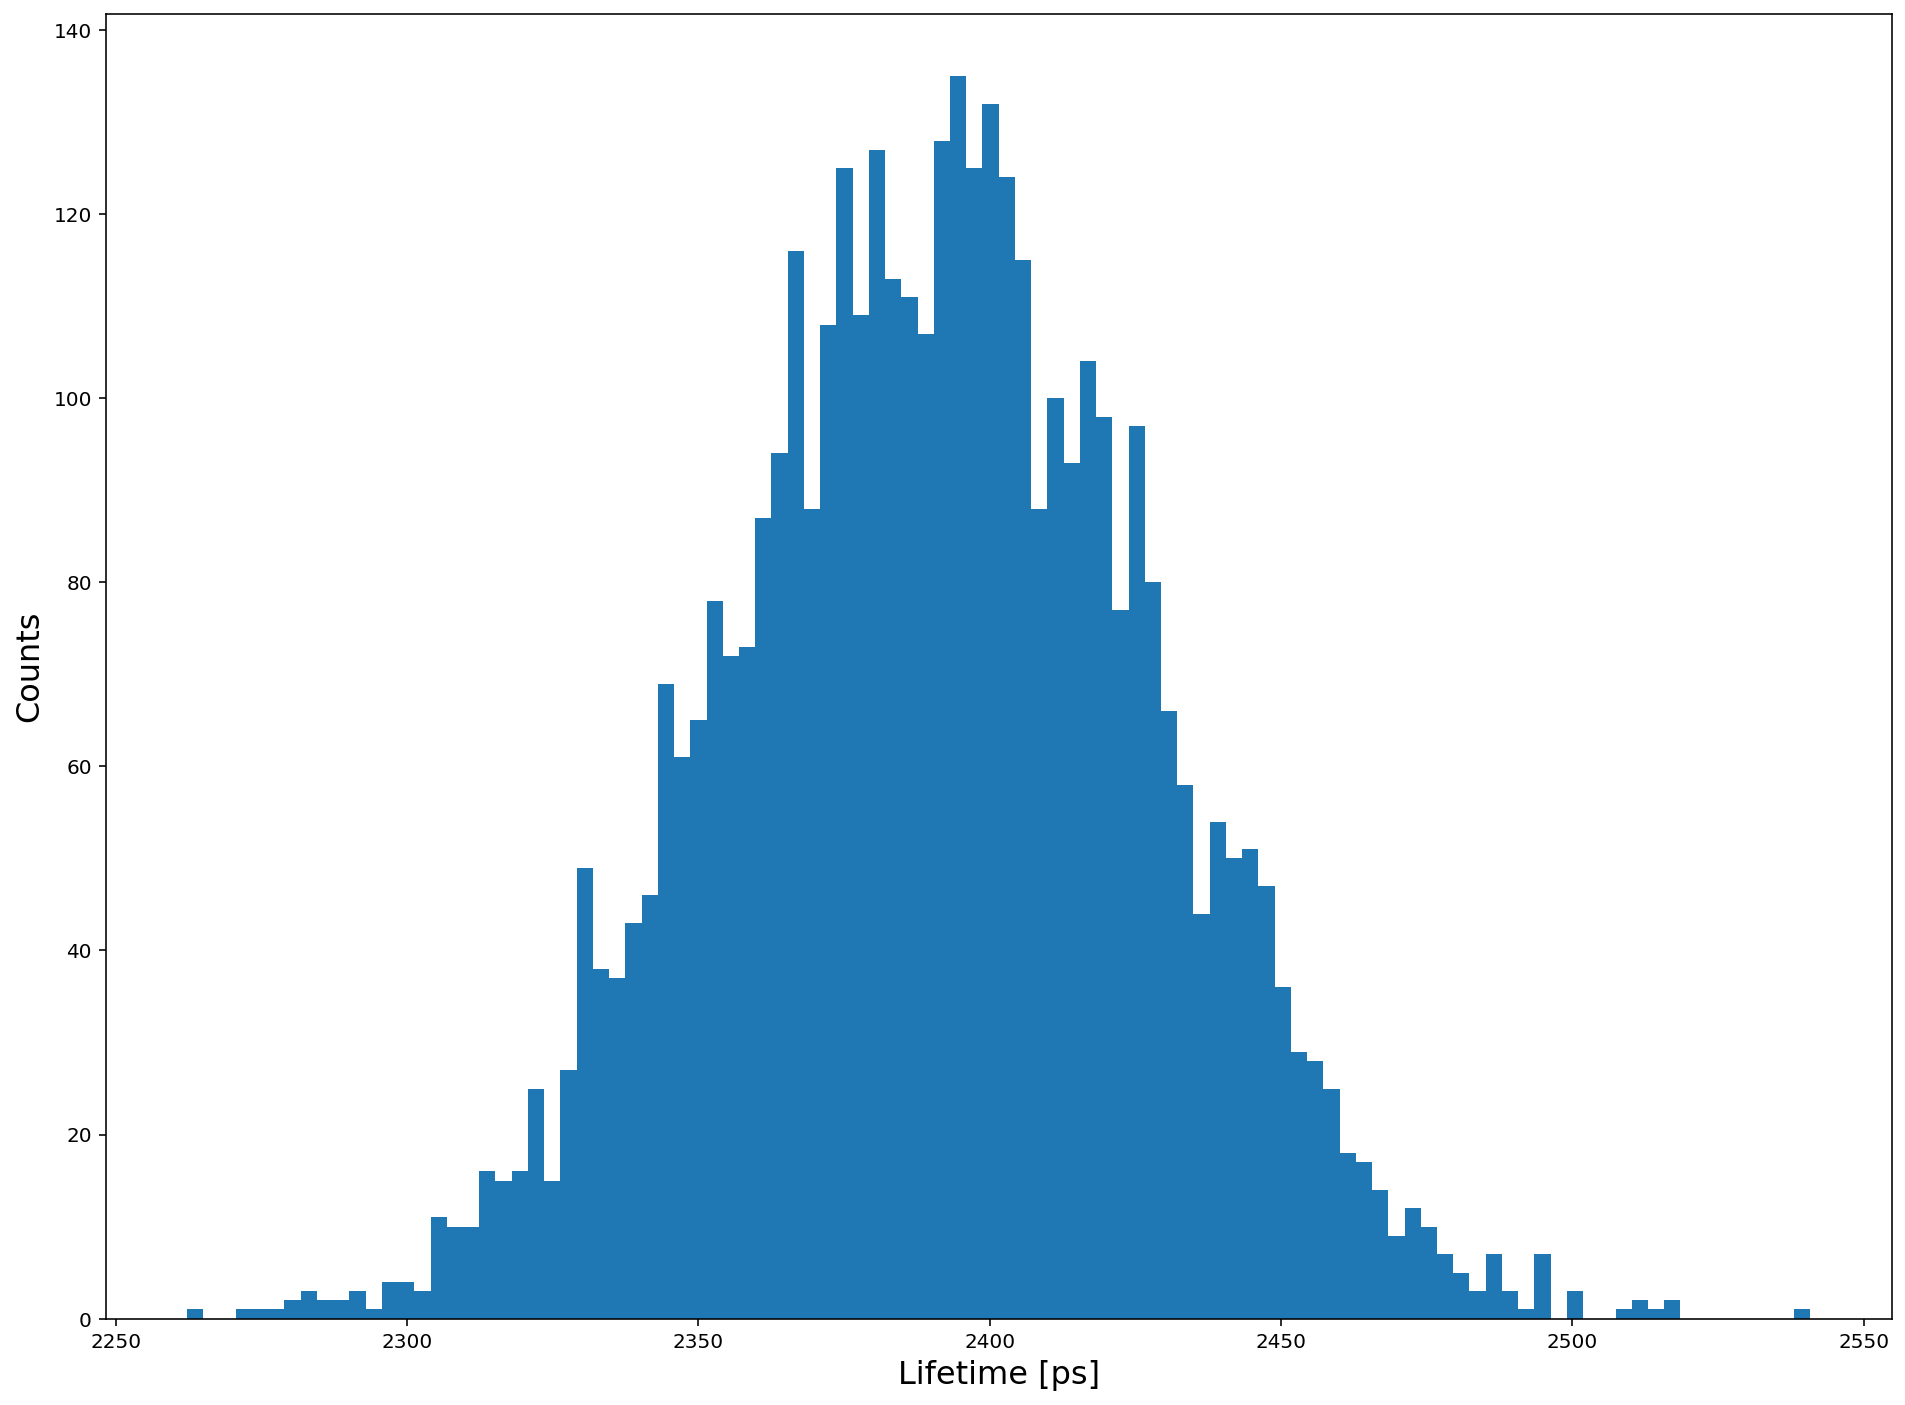

In [116]:
plt.hist(flim_image[:, :, 2].flatten(), bins = 100)
plt.xlabel('Lifetime [ps]')
plt.ylabel('Counts')
plt.show()

## Peak Maximum of Mirror-Measured IRF

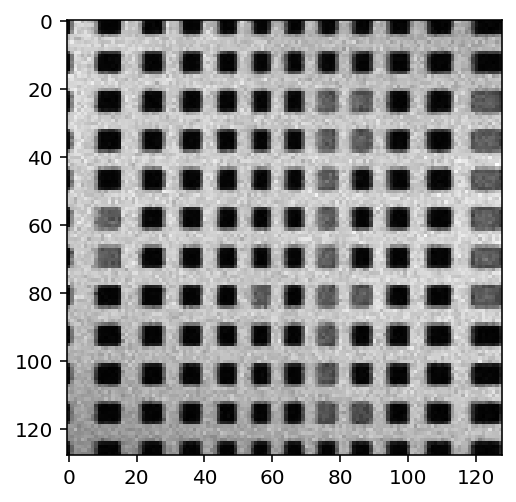

In [78]:
mirror, mirror_ii, time_axis = pq.load_flim_data(
    path = 'data/200302_Grid_Scan.sptw/200302_Grid_Zoom_4_7/200302_Grid_Zoom_4_7_1.ptu',
    spatialBinning = 3,
    temporalBinning = 4
)

plt.imshow(mirror_ii, cmap = 'gray')

In [81]:
peak_max = np.zeros((mirror.shape[0], mirror.shape[1]))

for x in range(mirror.shape[0]):
    for y in range(mirror.shape[1]):
        if(np.sum(mirror[x, y, :]) > 25):
            peak_max[x, y] = np.where(mirror[x, y, :] == np.amax(mirror[x, y, :]))[0][0]
        else:
            peak_max[x, y] = 0
            
peak_max *= 2**4

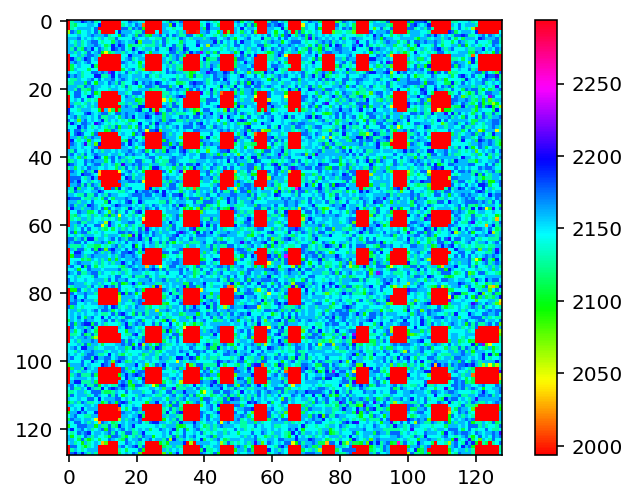

In [82]:
plt.imshow(peak_max,
           vmin = np.median(peak_max) - 150,
           vmax = np.median(peak_max) + 150,
          cmap = 'hsv')
plt.colorbar()
#plt.savefig('IRF_peak_shift_image.png', dpi = 350)
plt.show()

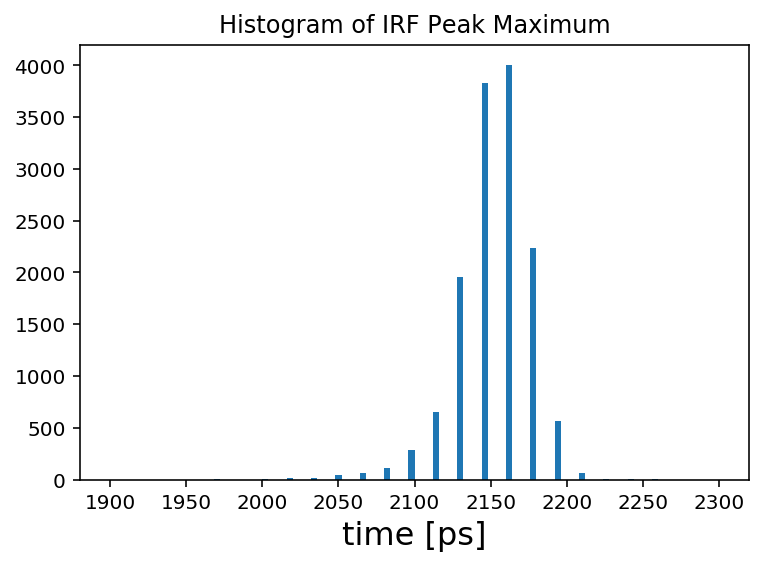

In [83]:
plt.hist(peak_max.flatten(), bins = 100, range = (1900, 2300))
plt.xlabel('time [ps]')
plt.title('Histogram of IRF Peak Maximum')
#plt.savefig('Hist_IRF_peak_time.png', dpi = 350)
plt.show()

## Gewichtete Summe eines simulierten Decays mit dieser Verteilung von IRF_mu!!!

In [77]:
time_axis

array([0.00000000e+00, 2.00004441e+00, 4.00008882e+00, ...,
       5.14091415e+04, 5.14111416e+04, 5.14131416e+04])